# Subnetwork Local Run + Review Notebook

This notebook is refactored for **local conda execution** and a full production-or-debug review cycle:

1. Validate local Python/conda environment and critical imports.
2. Run the orchestrator directly (`pipeline/run_subnetwork_pipeline.py`) from this notebook.
3. Write full runtime output to a text log.
4. Load generated outputs and run structured QA/debug checks.
5. Plot flux vs time for top reactions.



In [1]:
from pathlib import Path
import os
import sys
import subprocess
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from IPython.display import display

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 220)

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / 'pipeline').exists():
    raise RuntimeError(f"Run this notebook from repo root: {REPO_ROOT}")

PIPELINE_SCRIPT = REPO_ROOT / 'pipeline' / 'run_subnetwork_pipeline.py'

# Notebook run mode
USE_SHORT_TRIAL_30 = True  # True -> short local trial capped at 30 terminal products
SHORT_TRIAL_MAX_PRODUCTS = 30
SHORT_TRIAL_RANDOM_RETAIN = 5

if USE_SHORT_TRIAL_30:
    CONFIG_PATH = REPO_ROOT / 'pipeline' / 'configs' / 'pipeline_config.single_debug.yaml'
else:
    CONFIG_PATH = REPO_ROOT / 'pipeline' / 'configs' / 'pipeline_config.yaml'

NOTEBOOK_RUN_OVERRIDES = {}
if USE_SHORT_TRIAL_30:
    NOTEBOOK_RUN_OVERRIDES = {
        'max_products_per_network': int(SHORT_TRIAL_MAX_PRODUCTS),
        'random_flux_retain_count': int(min(SHORT_TRIAL_RANDOM_RETAIN, SHORT_TRIAL_MAX_PRODUCTS)),
    }

OUTPUT_ROOT = REPO_ROOT / 'subnetwork_outputs'
RUN_LOG = OUTPUT_ROOT / 'local_orchestrator_run.log'
NETWORK_DIR = REPO_ROOT / 'networks'
NETWORK_PICKLES = sorted(NETWORK_DIR.glob('*.pkl'))
if not NETWORK_PICKLES:
    raise RuntimeError(f"No network pickle files found under: {NETWORK_DIR}")

NETWORK_PICKLE = NETWORK_PICKLES[0]  # change if needed
TASK_ID = 1
RUN_PIPELINE = False  # Set to True to run the pipeline from this notebook (will block until completion)

cfg = yaml.safe_load(CONFIG_PATH.read_text()) or {}
if NOTEBOOK_RUN_OVERRIDES:
    cfg.update(NOTEBOOK_RUN_OVERRIDES)
sg_paths = ((cfg.get('subnetwork_gen') or {}).get('paths') or {})

PALETTE_CSV = REPO_ROOT / 'color_palettes' / 'colors_personal.csv'

def load_personal_colors(csv_path: Path) -> dict:
    if not csv_path.exists():
        raise FileNotFoundError(f'Palette CSV not found: {csv_path}')
    pal_df = pd.read_csv(csv_path)
    col_map = {str(c).strip().lower(): c for c in pal_df.columns}
    name_col = col_map.get('color name')
    hex_col = col_map.get('hex code')
    if not name_col or not hex_col:
        raise RuntimeError(f'Palette CSV must include columns: Color Name, Hex Code. Found: {list(pal_df.columns)}')

    out = {}
    for _, row in pal_df.iterrows():
        name = str(row[name_col]).strip()
        hex_code = str(row[hex_col]).strip()
        if not name or not hex_code or hex_code.lower() == 'nan':
            continue
        if not hex_code.startswith('#'):
            hex_code = f"#{hex_code.lstrip('#')}"
        out[name] = hex_code.upper()
    return out

PERSONAL_COLORS = load_personal_colors(PALETTE_CSV)

def c(name: str, fallback: str) -> str:
    return PERSONAL_COLORS.get(name, fallback)

# Darker line cycle drawn from your palette.
PLOT_COLOR_CYCLE = [
    c('Midnight Gridiron', '#11214F'),
    c('Ion Blue', '#1EA7FF'),
    c('Electric Emerald', '#00C853'),
    c('Gridiron Violet', '#6A37C8'),
    c('Edge Pink', '#FF5FA2'),
    c('Slate Line', '#3A4450'),
    c('Steel Grey', '#5A606B'),
    c('Flat Black', '#0D0D0D'),
    c('Iron Grey', '#2B2F33'),
    c('Brass', '#D4B56E'),
]
LINESTYLE_CYCLE = ['-', '--', '-.', ':']

# Fixed semantic style mapping by species role.
ROLE_COLORS = {
    'reagent': c('Ion Blue', '#1EA7FF'),
    'intermediate': c('Electric Emerald', '#00C853'),
    'co_product': c('Gridiron Violet', '#6A37C8'),
    'product': c('Edge Pink', '#FF5FA2'),
    'unknown': c('Slate Line', '#3A4450'),
}
ROLE_TAG = {
    'reagent': 'R',
    'intermediate': 'I',
    'co_product': 'CoP',
    'product': 'P',
    'unknown': '?',
}
ROLE_STYLE_VARIANTS = ['-', '-.', ':', '--']

# Centralized plotting controls for easy edits before sharing.
PLOT_CFG = {
    'max_reaction_lines': 12,
    'max_species_flux_lines': 10,
    'max_species_conc_lines': 12,
    'reaction_flux_log_y': False,
    'species_flux_log_y': False,
    'concentration_log_x': False,
    'concentration_log_y': False,
    'force_zero_anchor': True,
    'force_linear_for_zero': True,
    'single_point_marker': 'o',
    'single_point_size': 48,
    'legend_outside': True,
    'save_figures': False,
    'figure_dir': OUTPUT_ROOT / 'figures_share',
    'figure_dpi': 250,
}

def maybe_savefig(stem: str):
    if not PLOT_CFG.get('save_figures', False):
        return
    out_dir = Path(PLOT_CFG.get('figure_dir', OUTPUT_ROOT / 'figures_share'))
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / f"{stem}.png"
    plt.savefig(out_path, dpi=int(PLOT_CFG.get('figure_dpi', 250)), bbox_inches='tight')
    print(f'Saved figure: {out_path}')

plt.rcParams.update(
    {
        'figure.facecolor': c('Polar Mist', '#E6E9ED'),
        'axes.facecolor': c('Fog Silver', '#DDE2E7'),
        'axes.edgecolor': c('Slate Line', '#3A4450'),
        'axes.labelcolor': c('Flat Black', '#0D0D0D'),
        'axes.titlecolor': c('Flat Black', '#0D0D0D'),
        'xtick.color': c('Slate Line', '#3A4450'),
        'ytick.color': c('Slate Line', '#3A4450'),
        'axes.grid': False,
        'font.size': 11,
    }
)

print('Repo root:', REPO_ROOT)
print('Python exe:', sys.executable)
print('Conda env:', os.environ.get('CONDA_DEFAULT_ENV'))
print('Short-trial mode (30 products):', USE_SHORT_TRIAL_30)
print('Base config:', CONFIG_PATH)
print('Notebook overrides:', NOTEBOOK_RUN_OVERRIDES if NOTEBOOK_RUN_OVERRIDES else 'None')
print('Using network pickle:', NETWORK_PICKLE)
print('Run log path:', RUN_LOG)
print('Configured max_products_per_network:', cfg.get('max_products_per_network'))
print('Configured path cutoff:', sg_paths.get('cutoff'))
print('Using palette:', PALETTE_CSV)
print('Plot config:', PLOT_CFG)



Repo root: /Users/tburton2/Desktop/Projects/dblYAKS/subnetwork_kinetics
Python exe: /opt/anaconda3/envs/yarp-again/bin/python
Conda env: yarp-again
Short-trial mode (30 products): True
Base config: /Users/tburton2/Desktop/Projects/dblYAKS/subnetwork_kinetics/pipeline/configs/pipeline_config.single_debug.yaml
Notebook overrides: {'max_products_per_network': 30, 'random_flux_retain_count': 5}
Using network pickle: /Users/tburton2/Desktop/Projects/dblYAKS/subnetwork_kinetics/networks/C1CCCCC1.pkl
Run log path: /Users/tburton2/Desktop/Projects/dblYAKS/subnetwork_kinetics/subnetwork_outputs/local_orchestrator_run.log
Configured max_products_per_network: 30
Configured path cutoff: 4
Using palette: /Users/tburton2/Desktop/Projects/dblYAKS/subnetwork_kinetics/color_palettes/colors_personal.csv
Plot config: {'max_reaction_lines': 12, 'max_species_flux_lines': 10, 'max_species_conc_lines': 12, 'reaction_flux_log_y': False, 'species_flux_log_y': False, 'concentration_log_x': False, 'concentration

In [2]:
def ensure_yarp_path_from_config(config_path: Path):
    cfg = yaml.safe_load(config_path.read_text()) or {}
    yarp_path = cfg.get('yarp_path')
    if not yarp_path:
        return None
    yp = Path(yarp_path).expanduser().resolve()
    if not yp.exists():
        raise FileNotFoundError(f"Configured yarp_path does not exist: {yp}")
    yp_text = str(yp)
    if yp_text not in sys.path:
        sys.path.insert(0, yp_text)
    os.environ['PYTHONPATH'] = yp_text + (os.pathsep + os.environ['PYTHONPATH'] if os.environ.get('PYTHONPATH') else '')
    return yp


def check_module(mod_name):
    try:
        m = importlib.import_module(mod_name)
        return {'module': mod_name, 'ok': True, 'version': getattr(m, '__version__', 'n/a'), 'error': ''}
    except Exception as exc:
        return {'module': mod_name, 'ok': False, 'version': '', 'error': f"{type(exc).__name__}: {exc}"}


yarp_root = ensure_yarp_path_from_config(CONFIG_PATH)
print('Configured yarp_path:', yarp_root)

checks = [
    check_module('yaml'),
    check_module('pandas'),
    check_module('numpy'),
    check_module('matplotlib'),
    check_module('rdkit'),
    check_module('yarp'),
    check_module('cantera'),
]

check_df = pd.DataFrame(checks)
display(check_df)

missing = check_df.loc[~check_df['ok'], 'module'].tolist()
if missing:
    print('Missing modules detected:', ', '.join(missing))
else:
    print('All required modules import successfully.')

try:
    import yarp.network.network as yarp_network
    print('yarp.network.network loaded from:', Path(yarp_network.__file__).resolve())
except Exception as exc:
    print('Unable to import yarp.network.network:', exc)


Configured yarp_path: /Users/tburton2/Desktop/Repos/yarp-again


,module,ok,version,error
0,yaml,True,6.0.2,
1,pandas,True,2.3.2,
2,numpy,True,2.3.2,
3,matplotlib,True,3.10.5,
4,rdkit,True,2025.03.6,
5,yarp,True,n/a,
6,cantera,True,3.1.0,


All required modules import successfully.
yarp.network.network loaded from: /Users/tburton2/Desktop/Repos/yarp-again/yarp/network/network.py


In [3]:
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

RUN_CONFIG_PATH = CONFIG_PATH
if NOTEBOOK_RUN_OVERRIDES:
    runtime_cfg = yaml.safe_load(CONFIG_PATH.read_text()) or {}
    runtime_cfg.update(NOTEBOOK_RUN_OVERRIDES)
    RUN_CONFIG_PATH = OUTPUT_ROOT / '_notebook_runtime_config.yaml'
    RUN_CONFIG_PATH.write_text(yaml.safe_dump(runtime_cfg, sort_keys=False))
    print('Wrote notebook runtime config:', RUN_CONFIG_PATH)
    print('Applied notebook overrides:', NOTEBOOK_RUN_OVERRIDES)

cfg = yaml.safe_load(RUN_CONFIG_PATH.read_text()) or {}
sg_paths = ((cfg.get('subnetwork_gen') or {}).get('paths') or {})

if RUN_PIPELINE:
    cmd = [
        sys.executable,
        str(PIPELINE_SCRIPT),
        '--config', str(RUN_CONFIG_PATH),
        '--network-pickle', str(NETWORK_PICKLE),
        '--task-id', str(TASK_ID),
    ]
    print('Running command:')
    print(' '.join(cmd))

    with RUN_LOG.open('w') as logf:
        proc = subprocess.Popen(
            cmd,
            cwd=str(REPO_ROOT),
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True,
            bufsize=1,
        )
        assert proc.stdout is not None
        for line in proc.stdout:
            print(line, end='')
            logf.write(line)
        rc = proc.wait()

    print(f"\nProcess return code: {rc}")
    print(f"Log written to: {RUN_LOG}")
    if rc != 0:
        raise RuntimeError(f"Orchestrator failed with return code {rc}. See log: {RUN_LOG}")
else:
    print('RUN_PIPELINE=False, skipping orchestrator execution.')


Wrote notebook runtime config: /Users/tburton2/Desktop/Projects/dblYAKS/subnetwork_kinetics/subnetwork_outputs/_notebook_runtime_config.yaml
Applied notebook overrides: {'max_products_per_network': 30, 'random_flux_retain_count': 5}
RUN_PIPELINE=False, skipping orchestrator execution.


In [4]:
if RUN_LOG.exists():
    tail_n = 120
    lines = RUN_LOG.read_text(errors='replace').splitlines()
    print(f'Log tail ({min(len(lines), tail_n)} of {len(lines)} lines):')
    print('-' * 100)
    print('\n'.join(lines[-tail_n:]))
    print('-' * 100)
else:
    print('No run log found yet:', RUN_LOG)


Log tail (120 of 6036 lines):
----------------------------------------------------------------------------------------------------
C1CCCCC1__2900338.3082103_to_2681742.0838959.to_final.csv: rows=1
  reaction_index=11, reaction_name=reaction_11, equation=C1CC2CC2C1 + [H][H] => C1=C2CCCC12 + [H][H] + [H][H], orig_key=rxn_0000179, rxn_id=JAPMJSVZDUYFKL-UFHFLCQGNIYNRP_to_HQGBLJKANVZPHV-UFHFLCQGNIYNRP-UFHFLCQGNIYNRP, rxn_hash=5804500.605158737, source_type=I, from_smiles=C1CC2CC2C1.[H][H], to_smiles=C1=C2CCCC12.[H][H].[H][H], flux_to_final_species=0.0003926880712677396, flux_to_final_species_std=0.0020736207009074037, cumulative_abs_flux=0.0003926880712677383, cumulative_abs_flux_std=0.0020736207009073963, final_rate_of_progress=3.234465080965991e-07, final_rate_of_progress_std=8.825096126048822e-07
C1CCCCC1__2900338.3082103_to_2681742.0838959.flux_timeseries.csv: rows=63210
  time_s=0.0, reaction_index=1, reaction_name=reaction_1, equation=C1CCCCC1 => C1=CCCCC1 + [H][H], orig_key=rxn_00002

In [5]:
def _read_parquet_with_arrow_retry(path: Path) -> pd.DataFrame:
    try:
        return pd.read_parquet(path)
    except Exception as exc:
        if 'pandas.period already defined' not in str(exc):
            raise
        import pyarrow as pa
        for ext_name in ('pandas.period', 'pandas.interval'):
            try:
                pa.unregister_extension_type(ext_name)
            except Exception:
                pass
        import sys as _sys
        _sys.modules.pop('pandas.core.arrays.arrow.extension_types', None)
        return pd.read_parquet(path)


def load_table(base_path: Path) -> tuple[pd.DataFrame, Path]:
    if base_path.exists():
        if base_path.suffix == '.parquet':
            return _read_parquet_with_arrow_retry(base_path), base_path
        return pd.read_pickle(base_path), base_path
    pkl = base_path.with_suffix('.pkl')
    if pkl.exists():
        return pd.read_pickle(pkl), pkl
    raise FileNotFoundError(f'Could not find {base_path} or {pkl}')

network_dirs = sorted([p for p in OUTPUT_ROOT.glob('networks__*') if p.is_dir()], key=lambda p: p.stat().st_mtime)
if not network_dirs:
    raise RuntimeError(f'No network output dirs found in {OUTPUT_ROOT}. Run pipeline first.')

NETWORK_OUT = network_dirs[-1]
print('Using network output dir:', NETWORK_OUT)

terminal_df, terminal_path = load_table(NETWORK_OUT / 'terminal_products.parquet')
print('Terminal table:', terminal_path, '| rows:', len(terminal_df))
display(terminal_df.head(10))

product_paths = sorted(NETWORK_OUT.glob('product_*.parquet'))
if not product_paths:
    product_paths = sorted(NETWORK_OUT.glob('product_*.pkl'))
print('Product tables found:', len(product_paths))
for p in product_paths[:10]:
    print(' -', p.name)


Using network output dir: /Users/tburton2/Desktop/Projects/dblYAKS/subnetwork_kinetics/subnetwork_outputs/networks__C1CCCCC1
Terminal table: /Users/tburton2/Desktop/Projects/dblYAKS/subnetwork_kinetics/subnetwork_outputs/networks__C1CCCCC1/terminal_products.parquet | rows: 79


,product_hash,product_smiles,start_hash,start_smiles,network_pickle
0,1933711.3569986,CC1CC1,2900338.3082103,C1CCCCC1,/Users/tburton2/Desktop/Projects/dblYAKS/subne...
1,2418092.4259073,C=C(CC)CC,2900338.3082103,C1CCCCC1,/Users/tburton2/Desktop/Projects/dblYAKS/subne...
2,2579787.9487247,C1=CCCCC1,2900338.3082103,C1CCCCC1,/Users/tburton2/Desktop/Projects/dblYAKS/subne...
3,2681781.4809382,C1=C2CCC2C1,2900338.3082103,C1CCCCC1,/Users/tburton2/Desktop/Projects/dblYAKS/subne...
4,804929.133905,CC,2900338.3082103,C1CCCCC1,/Users/tburton2/Desktop/Projects/dblYAKS/subne...
5,1613161.3437451,C=C1CC1,2900338.3082103,C1CCCCC1,/Users/tburton2/Desktop/Projects/dblYAKS/subne...
6,321711.9270075,C,2900338.3082103,C1CCCCC1,/Users/tburton2/Desktop/Projects/dblYAKS/subne...
7,2096397.9754369,C1=CCCC1,2900338.3082103,C1CCCCC1,/Users/tburton2/Desktop/Projects/dblYAKS/subne...
8,2900696.2504432,CC1CCC1C,2900338.3082103,C1CCCCC1,/Users/tburton2/Desktop/Projects/dblYAKS/subne...
9,2418098.349787,C=C(C)CCC,2900338.3082103,C1CCCCC1,/Users/tburton2/Desktop/Projects/dblYAKS/subne...


Product tables found: 79
 - product_1028021.635145.parquet
 - product_1129602.2149457.parquet
 - product_1271089.6181478.parquet
 - product_1288301.5762805.parquet
 - product_1450151.5240963.parquet
 - product_1511387.4980949.parquet
 - product_1613006.2872464.parquet
 - product_1613161.3437451.parquet
 - product_1734470.9702691.parquet
 - product_1771689.5690614.parquet


In [6]:
completion_tol = float((((cfg.get('cantera_run_subnetworks') or {}).get('reactor') or {}).get('completion_tol', np.nan)))
completion_target = (1.0 - completion_tol) if np.isfinite(completion_tol) else np.nan
if np.isfinite(completion_target):
    print(f'Terminal-state completion audit target: X(state) >= {completion_target:.6g} (tol={completion_tol:.6g})')
else:
    print('Terminal-state completion audit target: unavailable (missing completion_tol in config)')

review_rows = []
for p in product_paths:
    df, loaded_path = load_table(p)
    cols = set(df.columns)
    roles = set(df.get('row_role', pd.Series(dtype=str)).astype(str))

    reagent_flux = float(df.loc[df['row_role'] == 'reagent', 'cumulative_flux_into_p_for_row'].sum()) if 'cumulative_flux_into_p_for_row' in cols else np.nan
    product_flux = float(df.loc[df['row_role'] == 'product', 'cumulative_flux_into_p_for_row'].sum()) if 'cumulative_flux_into_p_for_row' in cols else np.nan
    inter_flux_sum = float(df.loc[df['row_role'] == 'intermediate', 'cumulative_flux_into_p_for_row'].sum()) if 'cumulative_flux_into_p_for_row' in cols else np.nan

    product_end_concentration = np.nan
    if {'row_role', 'final_concentration'}.issubset(cols):
        pconc = pd.to_numeric(df.loc[df['row_role'] == 'product', 'final_concentration'], errors='coerce').dropna()
        if not pconc.empty:
            product_end_concentration = float(pconc.iloc[0])
    product_end_gap_to_one = (1.0 - product_end_concentration) if np.isfinite(product_end_concentration) else np.nan

    completion_terminal_species = ''
    if 'completion_terminal_species' in cols:
        cts = df['completion_terminal_species'].dropna().astype(str).str.strip()
        cts = cts[cts != '']
        if not cts.empty:
            completion_terminal_species = cts.iloc[0]

    completion_terminal_concentration = np.nan
    if 'completion_terminal_concentration' in cols:
        ctc = pd.to_numeric(df['completion_terminal_concentration'], errors='coerce').dropna()
        if not ctc.empty:
            completion_terminal_concentration = float(ctc.iloc[0])

    if not np.isfinite(completion_terminal_concentration):
        completion_species_list = [s for s in completion_terminal_species.split(';') if s]
        if completion_species_list and {'species_smiles', 'final_concentration'}.issubset(cols):
            subset = df[df['species_smiles'].astype(str).isin(completion_species_list)]
            completion_terminal_concentration = float(pd.to_numeric(subset['final_concentration'], errors='coerce').fillna(0.0).sum())
        elif np.isfinite(product_end_concentration):
            completion_terminal_concentration = float(product_end_concentration)

    completion_terminal_gap_to_one = (1.0 - completion_terminal_concentration) if np.isfinite(completion_terminal_concentration) else np.nan
    if np.isfinite(completion_terminal_concentration) and np.isfinite(completion_target):
        product_meets_completion_target = bool(completion_terminal_concentration >= completion_target)
    else:
        product_meets_completion_target = False

    inter_df = df[df.get('row_role', pd.Series(dtype=str)) == 'intermediate'].copy()
    on_target_mask = inter_df.get('is_on_target', pd.Series(False, index=inter_df.index)).fillna(False).astype(bool)
    on_target_inter = inter_df[on_target_mask]
    direct_on_target_mask = inter_df.get('is_direct_on_target', pd.Series(False, index=inter_df.index)).fillna(False).astype(bool)
    direct_on_target_inter = inter_df[direct_on_target_mask]

    nonzero_inter = int((inter_df.get('cumulative_flux_into_p_for_row', 0.0).fillna(0.0) > 0).sum()) if not inter_df.empty else 0

    req_flag_cols = [
        'included_forward_r_to_i_in_yaml',
        'included_reverse_i_to_r_in_yaml',
        'included_forward_i_to_p_in_yaml',
        'included_reverse_p_to_i_in_yaml',
    ]
    present_flag_cols = [c for c in req_flag_cols if c in inter_df.columns]
    if present_flag_cols and not inter_df.empty:
        nz = inter_df[inter_df['cumulative_flux_into_p_for_row'].fillna(0.0) > 0]
        all_false_on_nz = int((~nz[present_flag_cols].fillna(False).astype(bool).any(axis=1)).sum()) if not nz.empty else 0
    else:
        all_false_on_nz = 0

    on_target_missing_r_to_i = 0
    on_target_missing_i_to_r = 0
    on_target_missing_i_to_p = 0
    if not on_target_inter.empty:
        if 'included_forward_r_to_i_in_yaml' in on_target_inter.columns:
            on_target_missing_r_to_i = int((~on_target_inter['included_forward_r_to_i_in_yaml'].fillna(False).astype(bool)).sum())
        if 'included_reverse_i_to_r_in_yaml' in on_target_inter.columns:
            on_target_missing_i_to_r = int((~on_target_inter['included_reverse_i_to_r_in_yaml'].fillna(False).astype(bool)).sum())
        if 'included_forward_i_to_p_in_yaml' in on_target_inter.columns:
            on_target_missing_i_to_p = int((~on_target_inter['included_forward_i_to_p_in_yaml'].fillna(False).astype(bool)).sum())
    on_target_r_i_check_pass = bool(on_target_missing_r_to_i == 0 and on_target_missing_i_to_r == 0)

    direct_missing_reverse = 0
    if not direct_on_target_inter.empty and {'included_forward_r_to_i_in_yaml', 'included_reverse_i_to_r_in_yaml'}.issubset(set(direct_on_target_inter.columns)):
        d = direct_on_target_inter.copy()
        mask = d['included_forward_r_to_i_in_yaml'].fillna(False).astype(bool) & (~d['included_reverse_i_to_r_in_yaml'].fillna(False).astype(bool))
        direct_missing_reverse = int(mask.sum())

    has_direct_r_to_p = bool(df.get('included_direct_r_to_p_in_yaml', pd.Series([False])).fillna(False).astype(bool).any())
    has_reverse_p_to_r = bool(df.get('included_reverse_p_to_r_in_yaml', pd.Series([False])).fillna(False).astype(bool).any())

    direct_r_to_p_break_logic = 0
    if has_direct_r_to_p:
        if int((df.get('row_role', pd.Series(dtype=str)) == 'reagent').sum()) != 1:
            direct_r_to_p_break_logic += 1
        if int((df.get('row_role', pd.Series(dtype=str)) == 'product').sum()) != 1:
            direct_r_to_p_break_logic += 1

    review_rows.append(
        {
            'product_table': loaded_path.name,
            'rows': len(df),
            'n_reagent_rows': int((df['row_role'] == 'reagent').sum()) if 'row_role' in cols else 0,
            'n_intermediate_rows': int((df['row_role'] == 'intermediate').sum()) if 'row_role' in cols else 0,
            'n_product_rows': int((df['row_role'] == 'product').sum()) if 'row_role' in cols else 0,
            'n_on_target_intermediate_rows': int(len(on_target_inter)),
            'n_direct_on_target_intermediate_rows': int(len(direct_on_target_inter)),
            'on_target_missing_r_to_i': int(on_target_missing_r_to_i),
            'on_target_missing_i_to_r': int(on_target_missing_i_to_r),
            'on_target_missing_i_to_p': int(on_target_missing_i_to_p),
            'on_target_r_i_check_pass': bool(on_target_r_i_check_pass),
            'direct_on_target_missing_reverse': int(direct_missing_reverse),
            'has_direct_r_to_p_in_yaml': has_direct_r_to_p,
            'has_reverse_p_to_r_in_yaml': has_reverse_p_to_r,
            'direct_r_to_p_break_logic': int(direct_r_to_p_break_logic),
            'product_end_concentration': product_end_concentration,
            'product_end_gap_to_one': product_end_gap_to_one,
            'completion_terminal_species': completion_terminal_species,
            'completion_terminal_concentration': completion_terminal_concentration,
            'completion_terminal_gap_to_one': completion_terminal_gap_to_one,
            'product_meets_completion_target': bool(product_meets_completion_target),
            'reagent_flux': reagent_flux,
            'product_flux': product_flux,
            'intermediate_flux_sum': inter_flux_sum,
            'reagent_minus_product_flux': reagent_flux - product_flux if np.isfinite(reagent_flux) and np.isfinite(product_flux) else np.nan,
            'nonzero_intermediate_rows': nonzero_inter,
            'nonzero_intermediate_all_flags_false': all_false_on_nz,
            'missing_required_roles': sorted({'reagent', 'product'} - roles),
            'path': str(loaded_path),
        }
    )

review_df = pd.DataFrame(review_rows)
review_df = review_df.sort_values(
    ['on_target_missing_i_to_r', 'on_target_missing_r_to_i', 'direct_on_target_missing_reverse', 'completion_terminal_gap_to_one', 'reagent_minus_product_flux'],
    ascending=[False, False, False, False, False],
    key=lambda s: s.abs() if s.name in {'completion_terminal_gap_to_one', 'reagent_minus_product_flux'} else s,
)

print('Review summary across product tables:')
display(review_df)

print('Quick metrics:')
print(' - tables:', len(review_df))
print(' - tables with missing reagent/product roles:', int((review_df['missing_required_roles'].map(len) > 0).sum()))
print(' - tables with |reagent_flux - product_flux| > 1e-10:', int((review_df['reagent_minus_product_flux'].abs() > 1e-10).sum()))
print(' - tables with terminal-state completion below target:', int((~review_df['product_meets_completion_target']).sum()))
print(' - tables with on-target R<->I check failures:', int((~review_df['on_target_r_i_check_pass']).sum()))
print(' - tables with on-target missing I->P flags:', int((review_df['on_target_missing_i_to_p'] > 0).sum()))
print(' - tables with nonzero intermediate rows where all inclusion flags are false:', int((review_df['nonzero_intermediate_all_flags_false'] > 0).sum()))
print(' - tables with missing reverse into reagent on direct on-target intermediates:', int((review_df['direct_on_target_missing_reverse'] > 0).sum()))
print(' - tables with direct R->P where row-role logic looks broken:', int((review_df['direct_r_to_p_break_logic'] > 0).sum()))



Terminal-state completion audit target: X(state) >= 0.98 (tol=0.02)


/var/folders/qc/fg92hjk146s3g36x68b8n1lh0000gr/T/ipykernel_18361/1466294694.py:69: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  all_false_on_nz = int((~nz[present_flag_cols].fillna(False).astype(bool).any(axis=1)).sum()) if not nz.empty else 0
/var/folders/qc/fg92hjk146s3g36x68b8n1lh0000gr/T/ipykernel_18361/1466294694.py:78: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  on_target_missing_r_to_i = int((~on_target_inter['included_forward_r_to_i_in_yaml'].fillna(False).astype(bool)).sum())
/var/folders/qc/fg92hjk146s3g36x68b8n1lh0000gr/T/ipykernel_18361/14

Review summary across product tables:


/var/folders/qc/fg92hjk146s3g36x68b8n1lh0000gr/T/ipykernel_18361/1466294694.py:69: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  all_false_on_nz = int((~nz[present_flag_cols].fillna(False).astype(bool).any(axis=1)).sum()) if not nz.empty else 0
/var/folders/qc/fg92hjk146s3g36x68b8n1lh0000gr/T/ipykernel_18361/1466294694.py:78: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  on_target_missing_r_to_i = int((~on_target_inter['included_forward_r_to_i_in_yaml'].fillna(False).astype(bool)).sum())
/var/folders/qc/fg92hjk146s3g36x68b8n1lh0000gr/T/ipykernel_18361/14

,product_table,rows,n_reagent_rows,n_intermediate_rows,n_product_rows,n_on_target_intermediate_rows,n_direct_on_target_intermediate_rows,on_target_missing_r_to_i,on_target_missing_i_to_r,on_target_missing_i_to_p,on_target_r_i_check_pass,direct_on_target_missing_reverse,has_direct_r_to_p_in_yaml,has_reverse_p_to_r_in_yaml,direct_r_to_p_break_logic,product_end_concentration,product_end_gap_to_one,completion_terminal_species,completion_terminal_concentration,completion_terminal_gap_to_one,product_meets_completion_target,reagent_flux,product_flux,intermediate_flux_sum,reagent_minus_product_flux,nonzero_intermediate_rows,nonzero_intermediate_all_flags_false,missing_required_roles,path
51,product_2742000.802029.parquet,14,1,11,1,2,2,0,0,0,True,0,False,False,0,0.000119,0.999881,C1=CC2CCC12,0.000119,0.999881,False,2.124598e-07,2.124598e-07,0.000000,0.0,0,0,[],/Users/tburton2/Desktop/Projects/dblYAKS/subne...
50,product_2681781.4809382.parquet,14,1,11,1,2,2,0,0,0,True,0,False,False,0,0.001426,0.998574,C1=C2CCC2C1,0.001426,0.998574,False,7.246930e-06,7.246930e-06,0.000000,0.0,0,0,[],/Users/tburton2/Desktop/Projects/dblYAKS/subne...
73,product_3224918.7657205.parquet,14,1,11,1,2,2,0,0,0,True,0,False,False,0,0.002939,0.997061,C1C2C3CC2C13,0.002939,0.997061,False,5.236419e-06,5.236419e-06,0.000000,0.0,0,0,[],/Users/tburton2/Desktop/Projects/dblYAKS/subne...
44,product_2621562.2231759.parquet,14,1,11,1,2,2,0,0,0,True,0,False,False,0,0.012585,0.987415,C1CC2=C1CC2,0.012585,0.987415,False,2.243311e-05,2.243311e-05,0.000000,0.0,0,0,[],/Users/tburton2/Desktop/Projects/dblYAKS/subne...
38,product_2579955.7668879.parquet,4,1,1,1,1,1,0,0,0,True,0,False,False,0,0.047262,0.952738,CC1CC=CC1,0.047262,0.952738,False,8.752201e-05,8.752201e-05,0.000088,0.0,1,0,[],/Users/tburton2/Desktop/Projects/dblYAKS/subne...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21,product_2417943.2974632.parquet,6,1,4,1,4,4,0,0,0,True,0,True,False,0,0.999182,0.000818,CC=CCCC,0.999182,0.000818,True,5.323267e-04,5.323267e-04,0.000531,0.0,4,0,[],/Users/tburton2/Desktop/Projects/dblYAKS/subne...
56,product_2900696.7759536.parquet,17,1,15,1,6,6,0,0,0,True,0,True,False,0,0.999696,0.000304,CCC1CC1C,0.999696,0.000304,True,9.499901e-04,9.499901e-04,0.000946,0.0,4,0,[],/Users/tburton2/Desktop/Projects/dblYAKS/subne...
20,product_2417923.3833579.parquet,5,1,3,1,3,3,0,0,0,True,0,True,False,0,0.999819,0.000181,CCC=CCC,0.999819,0.000181,True,8.796626e-04,8.796626e-04,0.000872,0.0,3,0,[],/Users/tburton2/Desktop/Projects/dblYAKS/subne...
58,product_2900848.7426553.parquet,5,1,3,1,3,3,0,0,0,True,0,False,False,0,0.999983,0.000017,CCC1(C)CC1,0.999983,0.000017,True,9.552213e-04,9.552213e-04,0.000955,0.0,3,0,[],/Users/tburton2/Desktop/Projects/dblYAKS/subne...


Quick metrics:
 - tables: 79
 - tables with missing reagent/product roles: 0
 - tables with |reagent_flux - product_flux| > 1e-10: 0
 - tables with terminal-state completion below target: 68
 - tables with on-target R<->I check failures: 0
 - tables with on-target missing I->P flags: 0
 - tables with nonzero intermediate rows where all inclusion flags are false: 0
 - tables with missing reverse into reagent on direct on-target intermediates: 0
 - tables with direct R->P where row-role logic looks broken: 0


In [7]:
issue_df = review_df[
    (review_df['missing_required_roles'].map(len) > 0)
    | (review_df['reagent_minus_product_flux'].abs() > 1e-10)
    | (~review_df['product_meets_completion_target'])
    | (~review_df['on_target_r_i_check_pass'])
    | (review_df['on_target_missing_i_to_p'] > 0)
    | (review_df['nonzero_intermediate_all_flags_false'] > 0)
    | (review_df['direct_on_target_missing_reverse'] > 0)
    | (review_df['direct_r_to_p_break_logic'] > 0)
].copy()

if issue_df.empty:
    print('No major QA flags detected in product-level tables.')
else:
    print('Tables with QA flags:')
    display(issue_df[[
        'product_table',
        'completion_terminal_species',
        'completion_terminal_concentration',
        'product_end_concentration',
        'product_meets_completion_target',
        'on_target_missing_r_to_i',
        'on_target_missing_i_to_r',
        'on_target_missing_i_to_p',
        'on_target_r_i_check_pass',
        'direct_on_target_missing_reverse',
        'direct_r_to_p_break_logic',
        'reagent_minus_product_flux',
        'nonzero_intermediate_all_flags_false',
        'missing_required_roles',
    ]])

    print('Detailed preview for up to 3 flagged tables:')
    for _, row in issue_df.head(3).iterrows():
        path = Path(row['path'])
        df, _ = load_table(path)
        print('' + '=' * 120)
        print(path.name)
        cols = [
            'row_role', 'species_smiles', 'species_hash_primary', 'is_on_target', 'is_direct_on_target',
            'final_concentration',
            'completion_terminal_species', 'completion_terminal_concentration',
            'cumulative_flux_into_p_for_row', 'fraction_of_total_flux_into_p',
            'included_forward_r_to_i_in_yaml', 'included_reverse_i_to_r_in_yaml',
            'included_forward_i_to_p_in_yaml', 'included_reverse_p_to_i_in_yaml',
            'included_direct_r_to_p_in_yaml', 'included_reverse_p_to_r_in_yaml',
            'missing_reverse_into_reagent_on_direct_count',
            'r_to_current_forward_barrier', 'r_to_current_reverse_barrier',
        ]
        cols = [c for c in cols if c in df.columns]
        display(df[cols].head(40))



Tables with QA flags:


,product_table,completion_terminal_species,completion_terminal_concentration,product_end_concentration,product_meets_completion_target,on_target_missing_r_to_i,on_target_missing_i_to_r,on_target_missing_i_to_p,on_target_r_i_check_pass,direct_on_target_missing_reverse,direct_r_to_p_break_logic,reagent_minus_product_flux,nonzero_intermediate_all_flags_false,missing_required_roles
51,product_2742000.802029.parquet,C1=CC2CCC12,0.000119,0.000119,False,0,0,0,True,0,0,0.0,0,[]
50,product_2681781.4809382.parquet,C1=C2CCC2C1,0.001426,0.001426,False,0,0,0,True,0,0,0.0,0,[]
73,product_3224918.7657205.parquet,C1C2C3CC2C13,0.002939,0.002939,False,0,0,0,True,0,0,0.0,0,[]
44,product_2621562.2231759.parquet,C1CC2=C1CC2,0.012585,0.012585,False,0,0,0,True,0,0,0.0,0,[]
38,product_2579955.7668879.parquet,CC1CC=CC1,0.047262,0.047262,False,0,0,0,True,0,0,0.0,0,[]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,product_1028021.635145.parquet,C=CC,0.502206,0.502206,False,0,0,0,True,0,0,0.0,0,[]
4,product_1450151.5240963.parquet,C1CC1,0.516703,0.516703,False,0,0,0,True,0,0,0.0,0,[]
57,product_2900835.7806059.parquet,CC1(C)CCC1,0.937820,0.937820,False,0,0,0,True,0,0,0.0,0,[]
25,product_2478317.4085867.parquet,C=CCC(C)C,0.944979,0.944979,False,0,0,0,True,0,0,0.0,0,[]


Detailed preview for up to 3 flagged tables:
product_2742000.802029.parquet


,row_role,species_smiles,species_hash_primary,is_on_target,is_direct_on_target,final_concentration,completion_terminal_species,completion_terminal_concentration,cumulative_flux_into_p_for_row,fraction_of_total_flux_into_p,included_forward_r_to_i_in_yaml,included_reverse_i_to_r_in_yaml,included_forward_i_to_p_in_yaml,included_reverse_p_to_i_in_yaml,included_direct_r_to_p_in_yaml,included_reverse_p_to_r_in_yaml,missing_reverse_into_reagent_on_direct_count,r_to_current_forward_barrier,r_to_current_reverse_barrier
0,reagent,C1CCCCC1,2900338.3082103,True,False,5.031328e-04,C1=CC2CCC12,0.000119,2.124598e-07,1.0,None,None,None,None,False,False,0,None,None
1,intermediate,C1=CCCCC1,2579787.9487247,False,False,9.524225e-07,C1=CC2CCC12,0.000119,0.000000e+00,0.0,True,True,False,False,False,False,0,None,None
2,intermediate,C1CC1C1CC1,3062569.3312349,False,False,1.557492e-07,C1=CC2CCC12,0.000119,0.000000e+00,0.0,True,True,False,False,False,False,0,None,None
3,intermediate,C1CC2(C1)CC2,3062757.1474111,False,False,1.213074e-05,C1=CC2CCC12,0.000119,0.000000e+00,0.0,True,True,False,False,False,False,0,None,None
4,intermediate,C1CC2CC1C2,3062591.7695168,False,False,4.252849e-07,C1=CC2CCC12,0.000119,0.000000e+00,0.0,True,True,False,False,False,False,0,None,None
5,intermediate,C1CC2CC2C1,3062589.0716304,False,False,4.993207e-01,C1=CC2CCC12,0.000119,0.000000e+00,0.0,True,True,False,False,False,False,0,None,None
6,intermediate,C1CC2CCC12,3062605.0863143,True,True,2.057248e-06,C1=CC2CCC12,0.000119,0.000000e+00,0.0,True,True,True,False,False,False,0,None,None
7,intermediate,C=C1CCCC1,2579960.155387,False,False,8.064552e-07,C1=CC2CCC12,0.000119,0.000000e+00,0.0,True,True,False,False,False,False,0,None,None
8,intermediate,C=CC1CCC1,2640196.457282,False,False,2.302221e-04,C1=CC2CCC12,0.000119,0.000000e+00,0.0,True,True,False,False,False,False,0,None,None
9,intermediate,C=CCC1CC1,2640202.6144126,False,False,6.895794e-07,C1=CC2CCC12,0.000119,0.000000e+00,0.0,True,True,False,False,False,False,0,None,None


product_2681781.4809382.parquet


,row_role,species_smiles,species_hash_primary,is_on_target,is_direct_on_target,final_concentration,completion_terminal_species,completion_terminal_concentration,cumulative_flux_into_p_for_row,fraction_of_total_flux_into_p,included_forward_r_to_i_in_yaml,included_reverse_i_to_r_in_yaml,included_forward_i_to_p_in_yaml,included_reverse_p_to_i_in_yaml,included_direct_r_to_p_in_yaml,included_reverse_p_to_r_in_yaml,missing_reverse_into_reagent_on_direct_count,r_to_current_forward_barrier,r_to_current_reverse_barrier
0,reagent,C1CCCCC1,2900338.3082103,True,False,5.016248e-04,C1=C2CCC2C1,0.001426,0.000007,1.0,None,None,None,None,False,False,0,None,None
1,intermediate,C1=CCCCC1,2579787.9487247,False,False,9.483285e-07,C1=C2CCC2C1,0.001426,0.000000,0.0,True,True,False,False,False,False,0,None,None
2,intermediate,C1CC1C1CC1,3062569.3312349,False,False,1.541308e-07,C1=C2CCC2C1,0.001426,0.000000,0.0,True,True,False,False,False,False,0,None,None
3,intermediate,C1CC2(C1)CC2,3062757.1474111,False,False,1.503034e-05,C1=C2CCC2C1,0.001426,0.000000,0.0,True,True,False,False,False,False,0,None,None
4,intermediate,C1CC2CC1C2,3062591.7695168,False,False,4.234571e-07,C1=C2CCC2C1,0.001426,0.000000,0.0,True,True,False,False,False,False,0,None,None
5,intermediate,C1CC2CC2C1,3062589.0716304,False,False,4.973041e-01,C1=C2CCC2C1,0.001426,0.000000,0.0,True,True,False,False,False,False,0,None,None
6,intermediate,C1CC2CCC12,3062605.0863143,True,True,2.047905e-06,C1=C2CCC2C1,0.001426,0.000000,0.0,True,True,True,False,False,False,0,None,None
7,intermediate,C=C1CCCC1,2579960.155387,False,False,8.029892e-07,C1=C2CCC2C1,0.001426,0.000000,0.0,True,True,False,False,False,False,0,None,None
8,intermediate,C=CC1CCC1,2640196.457282,False,False,2.852492e-04,C1=C2CCC2C1,0.001426,0.000000,0.0,True,True,False,False,False,False,0,None,None
9,intermediate,C=CCC1CC1,2640202.6144126,False,False,6.866154e-07,C1=C2CCC2C1,0.001426,0.000000,0.0,True,True,False,False,False,False,0,None,None


product_3224918.7657205.parquet


,row_role,species_smiles,species_hash_primary,is_on_target,is_direct_on_target,final_concentration,completion_terminal_species,completion_terminal_concentration,cumulative_flux_into_p_for_row,fraction_of_total_flux_into_p,included_forward_r_to_i_in_yaml,included_reverse_i_to_r_in_yaml,included_forward_i_to_p_in_yaml,included_reverse_p_to_i_in_yaml,included_direct_r_to_p_in_yaml,included_reverse_p_to_r_in_yaml,missing_reverse_into_reagent_on_direct_count,r_to_current_forward_barrier,r_to_current_reverse_barrier
0,reagent,C1CCCCC1,2900338.3082103,True,False,4.999204e-04,C1C2C3CC2C13,0.002939,0.000005,1.0,None,None,None,None,False,False,0,None,None
1,intermediate,C1=CCCCC1,2579787.9487247,False,False,9.436824e-07,C1C2C3CC2C13,0.002939,0.000000,0.0,True,True,False,False,False,False,0,None,None
2,intermediate,C1CC1C1CC1,3062569.3312349,False,False,1.543392e-07,C1C2C3CC2C13,0.002939,0.000000,0.0,True,True,False,False,False,False,0,None,None
3,intermediate,C1CC2(C1)CC2,3062757.1474111,False,False,1.205867e-05,C1C2C3CC2C13,0.002939,0.000000,0.0,True,True,False,False,False,False,0,None,None
4,intermediate,C1CC2CC1C2,3062591.7695168,False,False,4.213829e-07,C1C2C3CC2C13,0.002939,0.000000,0.0,True,True,False,False,False,False,0,None,None
5,intermediate,C1CC2CC2C1,3062589.0716304,False,False,4.950939e-01,C1C2C3CC2C13,0.002939,0.000000,0.0,True,True,False,False,False,False,0,None,None
6,intermediate,C1CC2CCC12,3062605.0863143,True,True,2.037001e-06,C1C2C3CC2C13,0.002939,0.000000,0.0,True,True,True,False,False,False,0,None,None
7,intermediate,C=C1CCCC1,2579960.155387,False,False,7.990546e-07,C1C2C3CC2C13,0.002939,0.000000,0.0,True,True,False,False,False,False,0,None,None
8,intermediate,C=CC1CCC1,2640196.457282,False,False,2.288544e-04,C1C2C3CC2C13,0.002939,0.000000,0.0,True,True,False,False,False,False,0,None,None
9,intermediate,C=CCC1CC1,2640202.6144126,False,False,6.832515e-07,C1C2C3CC2C13,0.002939,0.000000,0.0,True,True,False,False,False,False,0,None,None


Flux timeseries table: /Users/tburton2/Desktop/Projects/dblYAKS/subnetwork_kinetics/subnetwork_outputs/networks__C1CCCCC1/random_flux_timeseries.parquet | rows: 1085
Reaction class labels in legend: {'I->P': 4, 'R->P': 1}
Top reactions plotted (cumulative): 12


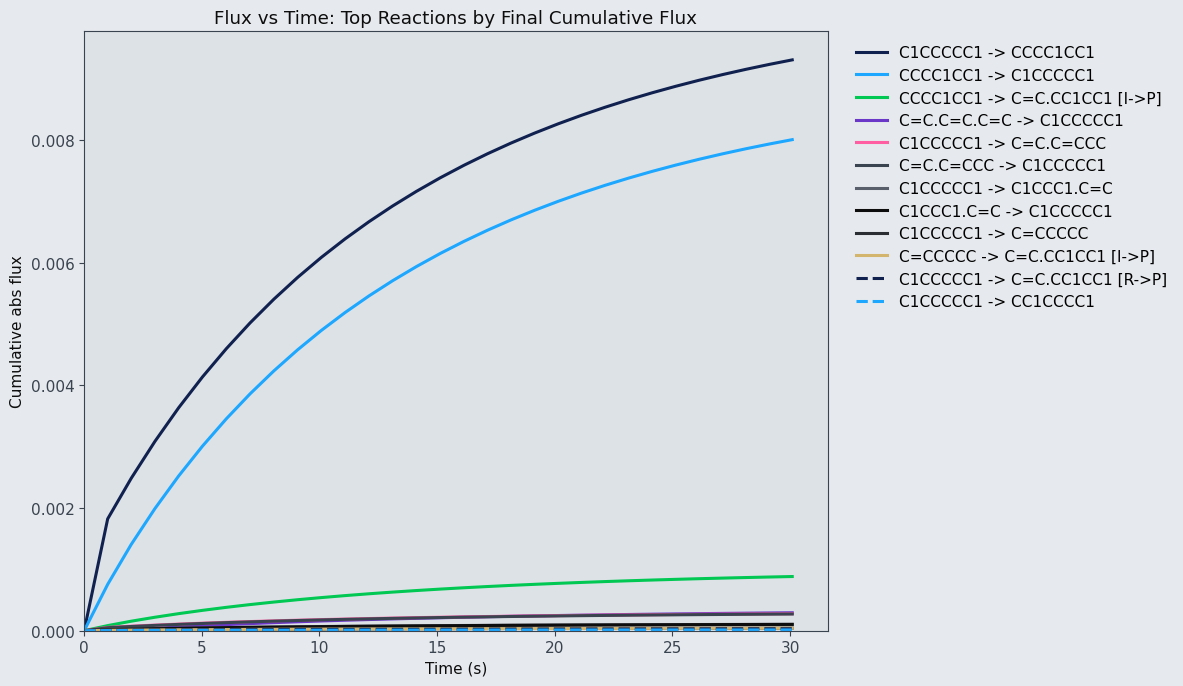

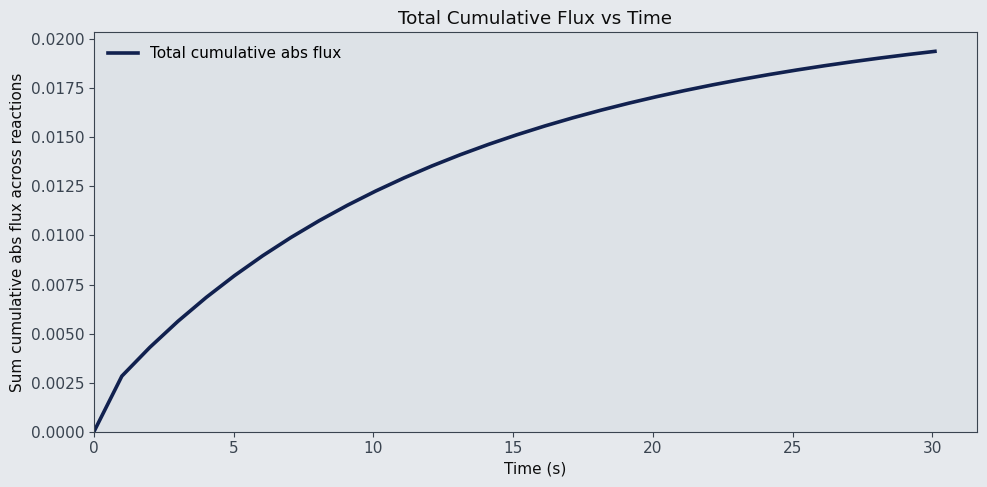

Instantaneous flux plot y-scale: linear


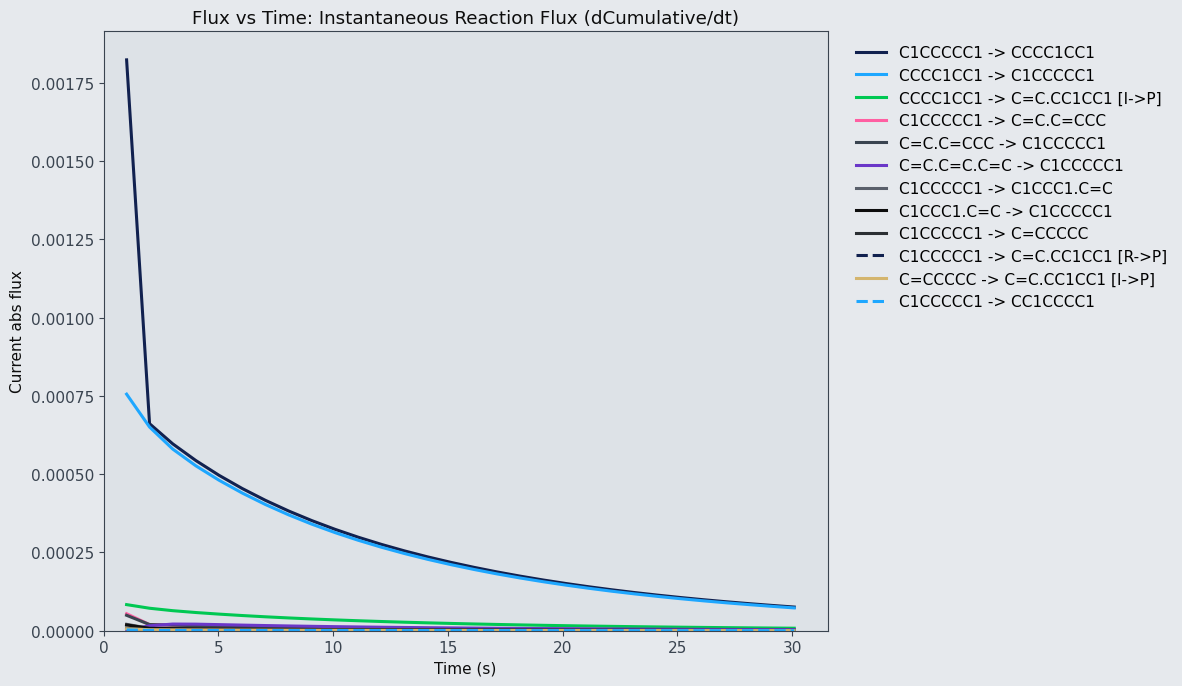

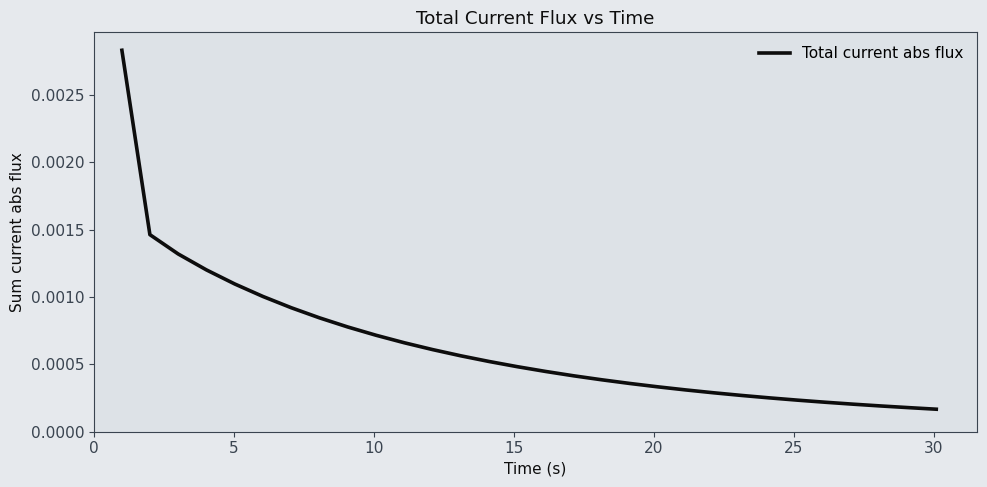

Instantaneous flux diagnostics:
 - reaction points: 510
 - unique time points: 30


In [8]:
random_flux_path = NETWORK_OUT / 'random_flux_timeseries.parquet'
if not random_flux_path.exists():
    random_flux_path = NETWORK_OUT / 'random_flux_timeseries.pkl'

if not random_flux_path.exists():
    alt_candidates = sorted(NETWORK_OUT.glob('random_flux_timeseries__*.parquet'))
    if not alt_candidates:
        alt_candidates = sorted(NETWORK_OUT.glob('random_flux_timeseries__*.pkl'))
    if alt_candidates:
        random_flux_path = alt_candidates[0]
        print(f'Primary random flux table not found; using: {random_flux_path.name}')

if not random_flux_path.exists():
    raise FileNotFoundError(f'Random flux table not found in {NETWORK_OUT}')

flux_df, flux_loaded_path = load_table(random_flux_path)
print('Flux timeseries table:', flux_loaded_path, '| rows:', len(flux_df))

if 'row_kind' in flux_df.columns:
    reaction_flux_df = flux_df[flux_df['row_kind'].fillna('').isin(['reaction_flux', ''])].copy()
    if reaction_flux_df.empty:
        reaction_flux_df = flux_df.copy()
else:
    reaction_flux_df = flux_df.copy()

required = {'time_s', 'cumulative_abs_flux'}
missing = required - set(reaction_flux_df.columns)
if missing:
    raise RuntimeError(f'Missing required columns in reaction flux table: {sorted(missing)}')

if 'reaction_label' not in reaction_flux_df.columns:
    if {'from_smiles', 'to_smiles'}.issubset(reaction_flux_df.columns):
        reaction_flux_df['reaction_label'] = reaction_flux_df['from_smiles'].fillna('?') + ' -> ' + reaction_flux_df['to_smiles'].fillna('?')
    else:
        reaction_flux_df['reaction_label'] = reaction_flux_df.get('orig_key', 'reaction').astype(str)

reaction_flux_df = reaction_flux_df.copy()
reaction_flux_df['time_s'] = pd.to_numeric(reaction_flux_df['time_s'], errors='coerce')
reaction_flux_df['cumulative_abs_flux'] = pd.to_numeric(reaction_flux_df['cumulative_abs_flux'], errors='coerce')
reaction_flux_df = reaction_flux_df.dropna(subset=['time_s', 'cumulative_abs_flux'])

if reaction_flux_df.empty:
    raise RuntimeError('No reaction flux rows with valid time/flux values.')

def _state_parts(state_text):
    return {p.strip() for p in str(state_text or '').split('.') if p and str(p).lower() != 'nan'}

target_reagent_smiles = None
target_product_smiles = None
if 'reagent_smiles' in reaction_flux_df.columns:
    rs = reaction_flux_df['reagent_smiles'].dropna().astype(str).str.strip()
    rs = rs[(rs != '') & (rs.str.lower() != 'nan')]
    if not rs.empty:
        target_reagent_smiles = rs.mode().iloc[0]
if 'product_smiles' in reaction_flux_df.columns:
    ps = reaction_flux_df['product_smiles'].dropna().astype(str).str.strip()
    ps = ps[(ps != '') & (ps.str.lower() != 'nan')]
    if not ps.empty:
        target_product_smiles = ps.mode().iloc[0]

reaction_class_by_label = {}
if {'reaction_label', 'from_smiles', 'to_smiles'}.issubset(reaction_flux_df.columns):
    meta_cols = ['reaction_label', 'from_smiles', 'to_smiles']
    if 'source_type' in reaction_flux_df.columns:
        meta_cols.append('source_type')
    rxn_meta = reaction_flux_df[meta_cols].dropna(subset=['reaction_label']).copy()
    rxn_meta = rxn_meta.drop_duplicates(subset=['reaction_label', 'from_smiles', 'to_smiles'], keep='last')

    for _, r in rxn_meta.iterrows():
        lbl = str(r['reaction_label'])
        from_parts = _state_parts(r.get('from_smiles', ''))
        to_parts = _state_parts(r.get('to_smiles', ''))
        source_type = str(r.get('source_type', '') or '').strip()
        tag = ''
        if target_product_smiles and target_product_smiles in to_parts:
            if (target_reagent_smiles and target_reagent_smiles in from_parts) or source_type == 'R':
                tag = 'R->P'
            elif source_type == 'I' or (target_reagent_smiles and target_reagent_smiles not in from_parts):
                tag = 'I->P'
        if tag:
            reaction_class_by_label[lbl] = tag

def decorate_reaction_label(lbl):
    tag = reaction_class_by_label.get(lbl, '')
    return f"{lbl} [{tag}]" if tag else lbl

if reaction_class_by_label:
    counts = pd.Series(list(reaction_class_by_label.values())).value_counts().to_dict()
    print('Reaction class labels in legend:', counts)

reaction_flux_df = (
    reaction_flux_df.groupby(['reaction_label', 'time_s'], as_index=False)['cumulative_abs_flux']
    .mean()
)

if bool(PLOT_CFG.get('force_zero_anchor', True)):
    labels_all = sorted(reaction_flux_df['reaction_label'].dropna().astype(str).unique().tolist())
    base = reaction_flux_df[reaction_flux_df['time_s'] > 0.0].copy()
    anchor = pd.DataFrame({
        'reaction_label': labels_all,
        'time_s': 0.0,
        'cumulative_abs_flux': 0.0,
    })
    reaction_flux_df = pd.concat([base, anchor], ignore_index=True)
    reaction_flux_df = (
        reaction_flux_df.groupby(['reaction_label', 'time_s'], as_index=False)['cumulative_abs_flux']
        .mean()
    )

final_by_rxn = (
    reaction_flux_df.sort_values(['reaction_label', 'time_s'])
    .groupby('reaction_label', as_index=False)
    .tail(1)
    .sort_values('cumulative_abs_flux', ascending=False)
)

top_n = min(int(PLOT_CFG.get('max_reaction_lines', 12)), len(final_by_rxn))
top_labels = final_by_rxn.head(top_n)['reaction_label'].tolist()
print(f'Top reactions plotted (cumulative): {top_n}')

style_map = {}
for i, lbl in enumerate(top_labels):
    color = PLOT_COLOR_CYCLE[i % len(PLOT_COLOR_CYCLE)]
    linestyle = LINESTYLE_CYCLE[(i // len(PLOT_COLOR_CYCLE)) % len(LINESTYLE_CYCLE)]
    style_map[lbl] = (color, linestyle)

def plot_line_or_point(x, y, *, color, linestyle, linewidth, label):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(x) <= 1:
        plt.scatter(
            x,
            y,
            color=color,
            s=float(PLOT_CFG.get('single_point_size', 48)),
            marker=str(PLOT_CFG.get('single_point_marker', 'o')),
            label=label,
        )
    else:
        plt.plot(x, y, linewidth=linewidth, color=color, linestyle=linestyle, label=label)

eps = 1.0e-20
use_log_reaction_y = bool(PLOT_CFG.get('reaction_flux_log_y', True))
if bool(PLOT_CFG.get('force_linear_for_zero', True)):
    use_log_reaction_y = False

plt.figure(figsize=(12, 7))
for lbl in top_labels:
    s = reaction_flux_df[reaction_flux_df['reaction_label'] == lbl].sort_values('time_s')
    x = s['time_s'].to_numpy(dtype=float)
    y_raw = s['cumulative_abs_flux'].to_numpy(dtype=float)
    y = np.clip(y_raw, eps, None) if use_log_reaction_y else np.clip(y_raw, 0.0, None)
    color, linestyle = style_map[lbl]
    plot_line_or_point(x, y, color=color, linestyle=linestyle, linewidth=2.2, label=decorate_reaction_label(lbl))

if use_log_reaction_y:
    plt.yscale('log')
plt.xlabel('Time (s)')
plt.ylabel('Cumulative abs flux' + (' (log scale)' if use_log_reaction_y else ''))
plt.title('Flux vs Time: Top Reactions by Final Cumulative Flux')
plt.xlim(left=0.0)
if not use_log_reaction_y:
    plt.ylim(bottom=0.0)
if top_n <= 8 or not bool(PLOT_CFG.get('legend_outside', True)):
    plt.legend(loc='best', frameon=False)
else:
    plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False)
plt.tight_layout()
maybe_savefig('reaction_cumulative_flux_vs_time')
plt.show()

# Aggregate curve for total tracked cumulative flux over time
total_ts = (
    reaction_flux_df.groupby('time_s', as_index=False)
    .agg(total_cumulative_abs_flux=('cumulative_abs_flux', 'sum'))
    .sort_values('time_s')
)
if bool(PLOT_CFG.get('force_zero_anchor', True)):
    total_ts = total_ts[total_ts['time_s'] > 0.0].copy()
    total_ts = pd.concat([
        pd.DataFrame({'time_s': [0.0], 'total_cumulative_abs_flux': [0.0]}),
        total_ts,
    ], ignore_index=True).sort_values('time_s')

y_raw = total_ts['total_cumulative_abs_flux'].to_numpy(dtype=float)
y = np.clip(y_raw, eps, None) if use_log_reaction_y else np.clip(y_raw, 0.0, None)

plt.figure(figsize=(10, 5))
plot_line_or_point(
    total_ts['time_s'].to_numpy(dtype=float),
    y,
    color=c('Midnight Gridiron', '#11214F'),
    linestyle='-',
    linewidth=2.6,
    label='Total cumulative abs flux',
)
if use_log_reaction_y:
    plt.yscale('log')
plt.xlabel('Time (s)')
plt.ylabel('Sum cumulative abs flux across reactions' + (' (log scale)' if use_log_reaction_y else ''))
plt.title('Total Cumulative Flux vs Time')
plt.xlim(left=0.0)
if not use_log_reaction_y:
    plt.ylim(bottom=0.0)
plt.legend(loc='best', frameon=False)
plt.tight_layout()
maybe_savefig('reaction_total_cumulative_flux_vs_time')
plt.show()

# Instantaneous/current flux estimate per reaction: d(cumulative_abs_flux)/dt
inst_rows = []
for lbl, grp in reaction_flux_df.groupby('reaction_label'):
    g = grp.sort_values('time_s')[['time_s', 'cumulative_abs_flux']]
    t = g['time_s'].to_numpy(dtype=float)
    cvals = g['cumulative_abs_flux'].to_numpy(dtype=float)
    if len(t) < 2:
        continue
    dt = np.diff(t)
    dc = np.diff(cvals)
    valid = dt > 0
    curr = np.zeros_like(dc)
    curr[valid] = dc[valid] / dt[valid]
    curr = np.clip(curr, 0.0, None)
    for ti, vi in zip(t[1:], curr):
        inst_rows.append({'time_s': float(ti), 'reaction_label': lbl, 'current_abs_flux': float(vi)})

inst_flux_df = pd.DataFrame(inst_rows)
if inst_flux_df.empty:
    print('No instantaneous flux points available (insufficient time resolution).')
else:
    current_by_rxn = (
        inst_flux_df.groupby('reaction_label', as_index=False)['current_abs_flux']
        .max()
        .sort_values('current_abs_flux', ascending=False)
    )
    top_current_labels = current_by_rxn.head(top_n)['reaction_label'].tolist()

    pos = inst_flux_df.loc[inst_flux_df['current_abs_flux'] > 0.0, 'current_abs_flux']
    yscale_current = 'linear'
    if not bool(PLOT_CFG.get('force_linear_for_zero', True)) and not pos.empty:
        dynamic_range = float(pos.max() / max(pos.min(), 1e-300))
        if dynamic_range >= 1.0e3:
            yscale_current = 'log'
    print(f'Instantaneous flux plot y-scale: {yscale_current}')

    plt.figure(figsize=(12, 7))
    for i, lbl in enumerate(top_current_labels):
        s = inst_flux_df[inst_flux_df['reaction_label'] == lbl].sort_values('time_s')
        x = s['time_s'].to_numpy(dtype=float)
        y = s['current_abs_flux'].to_numpy(dtype=float)
        if yscale_current == 'log':
            y = np.clip(y, eps, None)

        if lbl in style_map:
            color, linestyle = style_map[lbl]
        else:
            color = PLOT_COLOR_CYCLE[i % len(PLOT_COLOR_CYCLE)]
            linestyle = LINESTYLE_CYCLE[(i // len(PLOT_COLOR_CYCLE)) % len(LINESTYLE_CYCLE)]
        plot_line_or_point(x, y, color=color, linestyle=linestyle, linewidth=2.2, label=decorate_reaction_label(lbl))

    if yscale_current == 'log':
        plt.yscale('log')
    plt.xlabel('Time (s)')
    ylabel = 'Current abs flux (log scale)' if yscale_current == 'log' else 'Current abs flux'
    plt.ylabel(ylabel)
    plt.title('Flux vs Time: Instantaneous Reaction Flux (dCumulative/dt)')
    plt.xlim(left=0.0)
    if yscale_current != 'log':
        plt.ylim(bottom=0.0)
    if len(top_current_labels) <= 8 or not bool(PLOT_CFG.get('legend_outside', True)):
        plt.legend(loc='best', frameon=False)
    else:
        plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False)
    plt.tight_layout()
    maybe_savefig('reaction_instantaneous_flux_vs_time')
    plt.show()

    total_inst = (
        inst_flux_df.groupby('time_s', as_index=False)
        .agg(total_current_abs_flux=('current_abs_flux', 'sum'))
        .sort_values('time_s')
    )

    y_total = total_inst['total_current_abs_flux'].to_numpy(dtype=float)
    yscale_total = 'linear'
    pos_t = y_total[y_total > 0]
    if not bool(PLOT_CFG.get('force_linear_for_zero', True)) and len(pos_t) > 0:
        dr_t = float(pos_t.max() / max(pos_t.min(), 1e-300))
        if dr_t >= 1.0e3:
            yscale_total = 'log'
    if yscale_total == 'log':
        y_total = np.clip(y_total, eps, None)

    plt.figure(figsize=(10, 5))
    plot_line_or_point(
        total_inst['time_s'].to_numpy(dtype=float),
        y_total,
        color=c('Flat Black', '#0D0D0D'),
        linestyle='-',
        linewidth=2.6,
        label='Total current abs flux',
    )
    if yscale_total == 'log':
        plt.yscale('log')
    plt.xlabel('Time (s)')
    ylabel_total = 'Sum current abs flux (log scale)' if yscale_total == 'log' else 'Sum current abs flux'
    plt.ylabel(ylabel_total)
    plt.title('Total Current Flux vs Time')
    plt.xlim(left=0.0)
    if yscale_total != 'log':
        plt.ylim(bottom=0.0)
    plt.legend(loc='best', frameon=False)
    plt.tight_layout()
    maybe_savefig('reaction_total_current_flux_vs_time')
    plt.show()

    print('Instantaneous flux diagnostics:')
    print(' - reaction points:', len(inst_flux_df))
    print(' - unique time points:', int(inst_flux_df['time_s'].nunique()))


/var/folders/qc/fg92hjk146s3g36x68b8n1lh0000gr/T/ipykernel_18361/405788491.py:65: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  priority = final_flux[final_flux.get('is_on_target', False).fillna(False)].copy() if 'is_on_target' in final_flux.columns else pd.DataFrame()


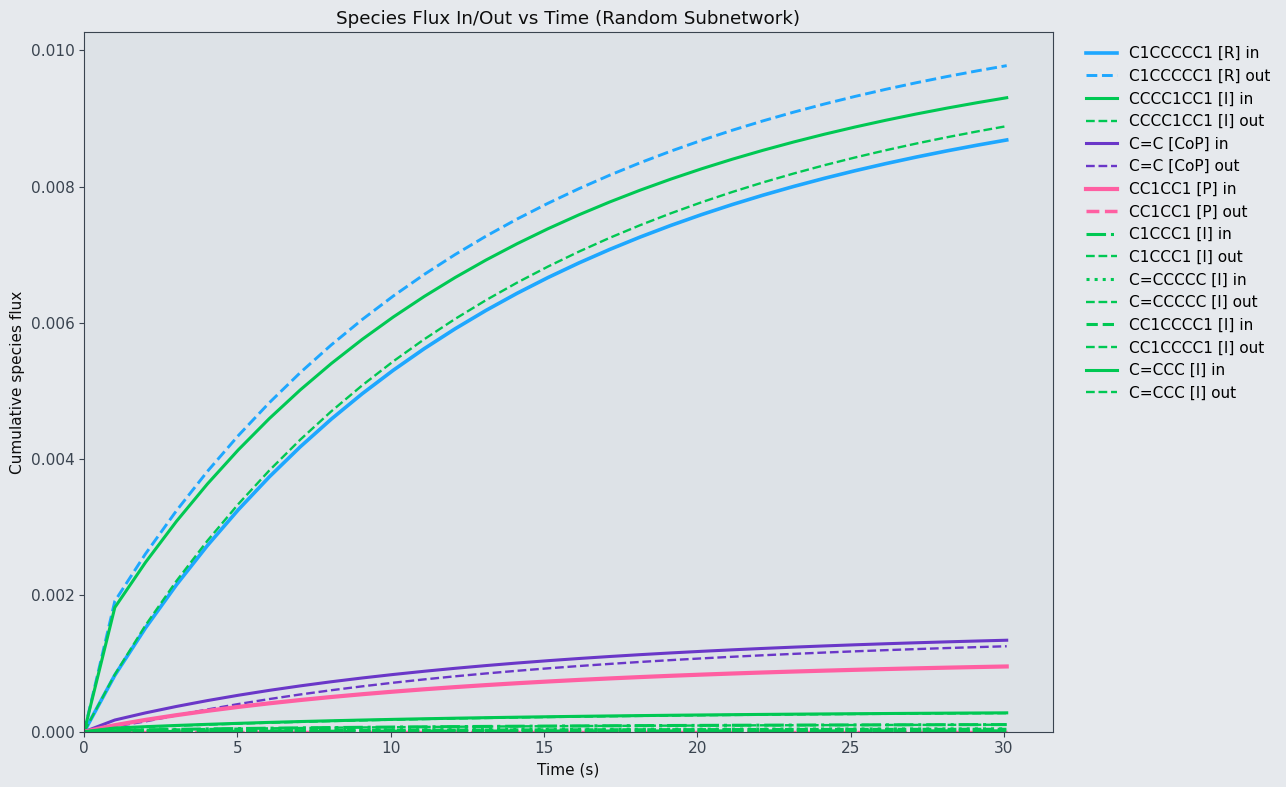

Final species flux snapshot (top 20 by max(in,out)):


,species_smiles,cumulative_in_flux,cumulative_out_flux,is_on_target,row_role
61,C1CCCCC1,0.008683,0.009774,True,reagent
247,CCCC1CC1,0.009303,0.008886,True,intermediate
92,C=C,0.001342,0.001254,True,co_product
185,CC1CC1,0.000957,0.000000,True,product
123,C=CCC,0.000277,0.000272,False,intermediate
30,C1CCC1,0.000105,0.000103,True,intermediate
154,C=CCCCC,0.000042,0.000041,True,intermediate
216,CC1CCCC1,0.000013,0.000013,True,intermediate


In [9]:
# Species flux-in / flux-out diagnostic plot for the random selected subnetwork
species_flux_df = pd.DataFrame()
if 'row_kind' in flux_df.columns:
    species_flux_df = flux_df[flux_df['row_kind'].fillna('') == 'species_flux'].copy()

if species_flux_df.empty:
    print('No species_flux rows available in random flux output. Re-run pipeline with updated code.')
else:
    required_cols = {'time_s', 'species_smiles', 'cumulative_in_flux', 'cumulative_out_flux'}
    missing_cols = required_cols - set(species_flux_df.columns)
    if missing_cols:
        raise RuntimeError(f'Missing required species flux columns: {sorted(missing_cols)}')

    species_flux_df['time_s'] = pd.to_numeric(species_flux_df['time_s'], errors='coerce')
    species_flux_df['cumulative_in_flux'] = pd.to_numeric(species_flux_df['cumulative_in_flux'], errors='coerce')
    species_flux_df['cumulative_out_flux'] = pd.to_numeric(species_flux_df['cumulative_out_flux'], errors='coerce')
    species_flux_df = species_flux_df.dropna(subset=['time_s', 'species_smiles', 'cumulative_in_flux', 'cumulative_out_flux'])

    # De-duplicate rows introduced by multi-role expansion (same species/time, multiple row_role values).
    if 'row_role' in species_flux_df.columns:
        role_priority = {'product': 0, 'co_product': 1, 'intermediate': 2, 'reagent': 3}
        species_flux_df['_role_order'] = species_flux_df['row_role'].astype(str).map(role_priority).fillna(9)
        species_flux_df = (
            species_flux_df
            .sort_values(['species_smiles', 'time_s', '_role_order'])
            .drop_duplicates(subset=['species_smiles', 'time_s'], keep='first')
            .drop(columns=['_role_order'])
        )
    else:
        species_flux_df = species_flux_df.sort_values(['species_smiles', 'time_s']).drop_duplicates(subset=['species_smiles', 'time_s'], keep='first')

    meta_cols = [c for c in ['row_role', 'is_on_target', 'is_direct_on_target'] if c in species_flux_df.columns]
    species_meta = (
        species_flux_df.sort_values(['species_smiles', 'time_s'])
        .groupby('species_smiles', as_index=False)
        .tail(1)[['species_smiles'] + meta_cols]
        if meta_cols else pd.DataFrame({'species_smiles': species_flux_df['species_smiles'].dropna().astype(str).unique().tolist()})
    )

    if bool(PLOT_CFG.get('force_zero_anchor', True)):
        all_species = sorted(species_flux_df['species_smiles'].dropna().astype(str).unique().tolist())
        species_flux_df = species_flux_df[species_flux_df['time_s'] > 0.0].copy()
        anchor = pd.DataFrame({
            'time_s': 0.0,
            'species_smiles': all_species,
            'cumulative_in_flux': 0.0,
            'cumulative_out_flux': 0.0,
        })
        species_flux_df = pd.concat([species_flux_df, anchor], ignore_index=True)
        species_flux_df = (
            species_flux_df.groupby(['species_smiles', 'time_s'], as_index=False)[['cumulative_in_flux', 'cumulative_out_flux']]
            .mean()
        )

    species_flux_df = species_flux_df.merge(species_meta, on='species_smiles', how='left')

    final_flux = (
        species_flux_df.sort_values(['species_smiles', 'time_s'])
        .groupby('species_smiles', as_index=False)
        .tail(1)
    )
    final_flux['max_io'] = final_flux[['cumulative_in_flux', 'cumulative_out_flux']].max(axis=1)

    # Plot reagent/product + on-target species first, then strongest remaining species
    priority = final_flux[final_flux.get('is_on_target', False).fillna(False)].copy() if 'is_on_target' in final_flux.columns else pd.DataFrame()
    selected_species = priority.sort_values('max_io', ascending=False)['species_smiles'].tolist()
    for s in final_flux.sort_values('max_io', ascending=False)['species_smiles'].tolist():
        if s not in selected_species:
            selected_species.append(s)
    selected_species = selected_species[: int(PLOT_CFG.get('max_species_flux_lines', 10))]

    role_by_species = {}
    if 'row_role' in final_flux.columns:
        role_by_species = {
            str(r['species_smiles']): str(r['row_role'])
            for _, r in final_flux[['species_smiles', 'row_role']].iterrows()
        }

    eps = 1.0e-20
    use_log_species_flux_y = bool(PLOT_CFG.get('species_flux_log_y', True))
    if bool(PLOT_CFG.get('force_linear_for_zero', True)):
        use_log_species_flux_y = False

    plt.figure(figsize=(13, 8))
    role_counts = {}
    for smi in selected_species:
        s = species_flux_df[species_flux_df['species_smiles'] == smi].sort_values('time_s')
        x = s['time_s'].to_numpy(dtype=float)
        in_raw = s['cumulative_in_flux'].to_numpy(dtype=float)
        out_raw = s['cumulative_out_flux'].to_numpy(dtype=float)
        if use_log_species_flux_y:
            in_y = np.clip(in_raw, eps, None)
            out_y = np.clip(out_raw, eps, None)
        else:
            in_y = np.clip(in_raw, 0.0, None)
            out_y = np.clip(out_raw, 0.0, None)

        role = role_by_species.get(smi, 'unknown')
        role_i = role_counts.get(role, 0)
        role_counts[role] = role_i + 1

        color = ROLE_COLORS.get(role, ROLE_COLORS['unknown'])
        in_style = ROLE_STYLE_VARIANTS[role_i % len(ROLE_STYLE_VARIANTS)]
        tag = ROLE_TAG.get(role, '?')

        base_lw = 2.2
        if role == 'product':
            base_lw = 3.0
        elif role == 'reagent':
            base_lw = 2.6

        label_prefix = f"{smi} [{tag}]"
        if len(x) <= 1:
            plt.scatter(x, in_y, color=color, s=float(PLOT_CFG.get('single_point_size', 48)), marker=str(PLOT_CFG.get('single_point_marker', 'o')), label=f"{label_prefix} in")
            plt.scatter(x, out_y, color=color, s=float(PLOT_CFG.get('single_point_size', 42)), marker='x', label=f"{label_prefix} out")
        else:
            plt.plot(x, in_y, linewidth=base_lw, color=color, linestyle=in_style, label=f"{label_prefix} in")
            plt.plot(x, out_y, linewidth=max(1.6, base_lw - 0.5), color=color, linestyle='--', label=f"{label_prefix} out")

    if use_log_species_flux_y:
        plt.yscale('log')
    plt.xlabel('Time (s)')
    plt.ylabel('Cumulative species flux' + (' (log scale)' if use_log_species_flux_y else ''))
    plt.title('Species Flux In/Out vs Time (Random Subnetwork)')
    plt.xlim(left=0.0)
    if not use_log_species_flux_y:
        plt.ylim(bottom=0.0)
    if bool(PLOT_CFG.get('legend_outside', True)):
        plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False)
    else:
        plt.legend(loc='best', frameon=False)
    plt.tight_layout()
    maybe_savefig('species_flux_in_out_vs_time')
    plt.show()

    print('Final species flux snapshot (top 20 by max(in,out)):')
    show_cols = [
        'species_smiles',
        'cumulative_in_flux',
        'cumulative_in_flux_std',
        'cumulative_out_flux',
        'cumulative_out_flux_std',
        'is_on_target',
        'row_role',
    ]
    show_cols = [c for c in show_cols if c in final_flux.columns]
    display(final_flux.sort_values('max_io', ascending=False)[show_cols].head(20))


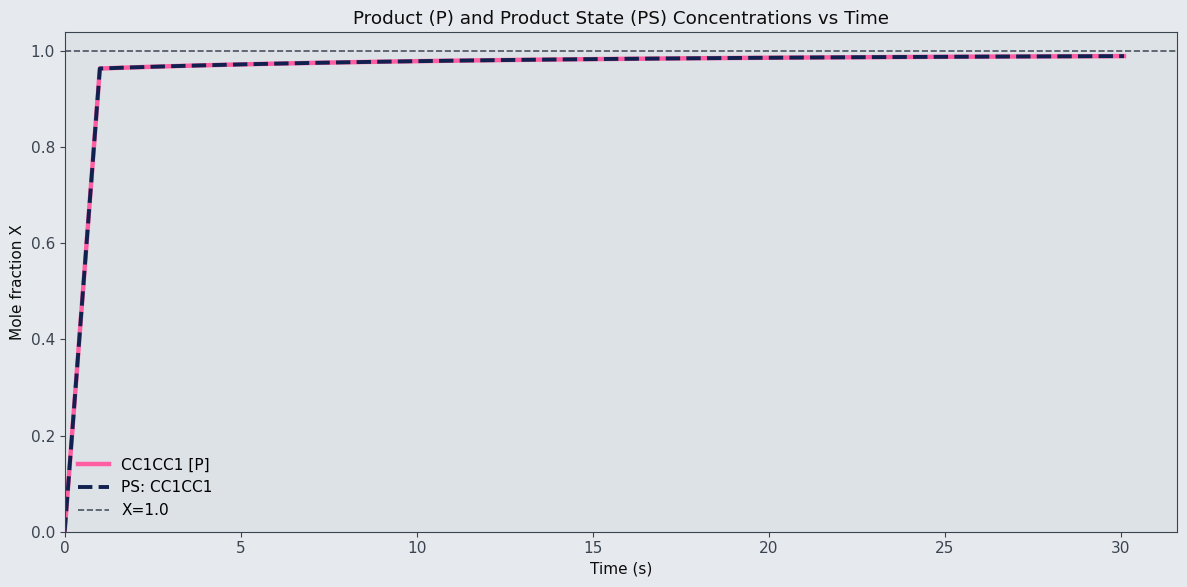

PS source: fallback
PS selected state: CC1CC1
Final [P]: 0.988609
Final [PS]: 0.988609


/var/folders/qc/fg92hjk146s3g36x68b8n1lh0000gr/T/ipykernel_18361/3353617023.py:219: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  on_target_mask = final_conc.get('is_on_target', pd.Series(False, index=final_conc.index)).fillna(False).astype(bool)


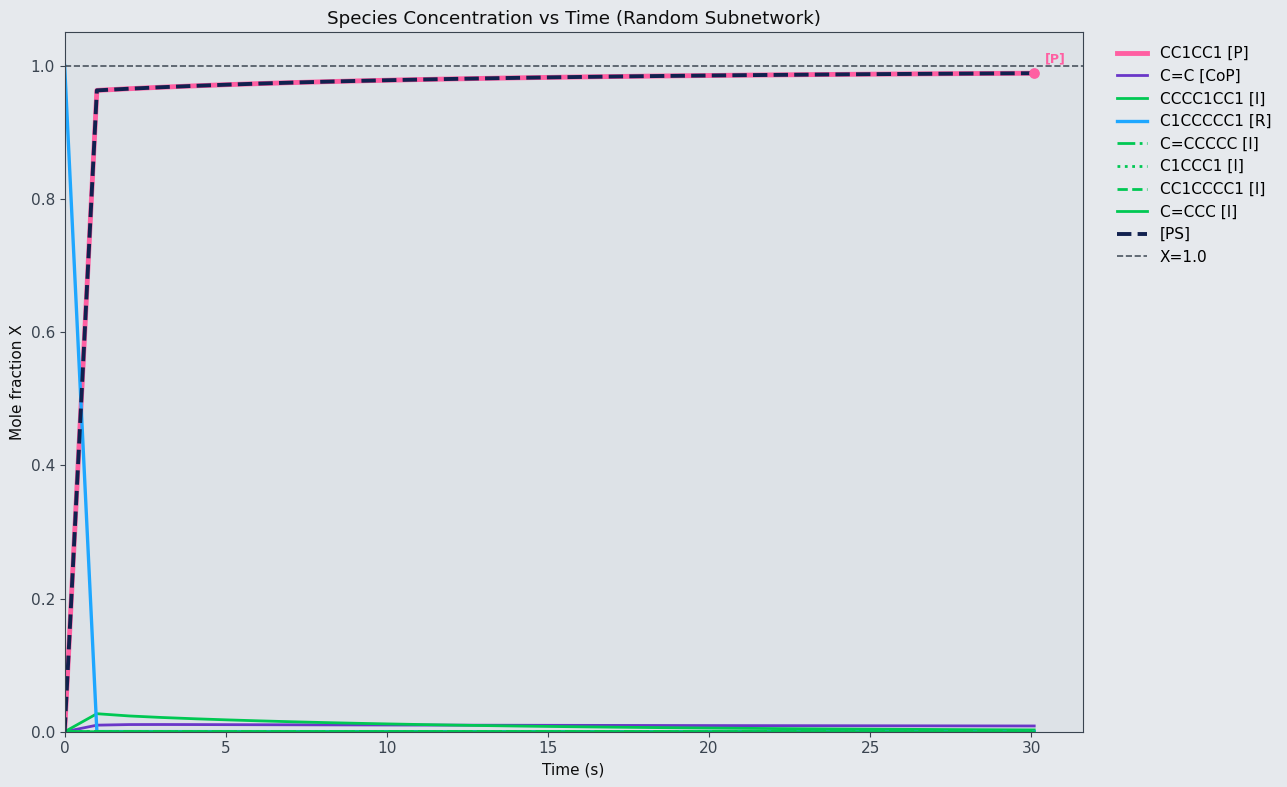

Final concentration snapshot (top 20):


,species_smiles,concentration_x,is_on_target,is_direct_on_target,row_role
185,CC1CC1,9.886091e-01,True,False,product
92,C=C,8.631796e-03,True,True,co_product
247,CCCC1CC1,2.733809e-03,True,True,intermediate
61,C1CCCCC1,1.939258e-05,True,False,reagent
154,C=CCCCC,3.667886e-06,True,True,intermediate
123,C=CCC,1.204392e-06,False,False,intermediate
30,C1CCC1,9.915515e-07,True,True,intermediate
216,CC1CCCC1,3.331664e-08,True,True,intermediate


In [10]:
# Species concentration (X) vs time for the same random selected subnetwork
conc_df = pd.DataFrame()
if 'row_kind' in flux_df.columns:
    conc_df = flux_df[flux_df['row_kind'].fillna('') == 'species_concentration'].copy()

if conc_df.empty:
    print('No species_concentration rows available in random flux output. Re-run pipeline with updated code.')
else:
    required_cols = {'time_s', 'species_smiles', 'concentration_x'}
    missing_cols = required_cols - set(conc_df.columns)
    if missing_cols:
        raise RuntimeError(f'Missing required concentration columns: {sorted(missing_cols)}')

    conc_df['time_s'] = pd.to_numeric(conc_df['time_s'], errors='coerce')
    conc_df['concentration_x'] = pd.to_numeric(conc_df['concentration_x'], errors='coerce')
    conc_df = conc_df.dropna(subset=['time_s', 'species_smiles', 'concentration_x'])

    # De-duplicate rows introduced by multi-role expansion (same species/time, multiple row_role values).
    if 'row_role' in conc_df.columns:
        role_priority = {'product': 0, 'co_product': 1, 'intermediate': 2, 'reagent': 3}
        conc_df['_role_order'] = conc_df['row_role'].astype(str).map(role_priority).fillna(9)
        conc_df = (
            conc_df
            .sort_values(['species_smiles', 'time_s', '_role_order'])
            .drop_duplicates(subset=['species_smiles', 'time_s'], keep='first')
            .drop(columns=['_role_order'])
        )
    else:
        conc_df = conc_df.sort_values(['species_smiles', 'time_s']).drop_duplicates(subset=['species_smiles', 'time_s'], keep='first')

    reagent_smiles = None
    if 'row_role' in conc_df.columns:
        r_rows = conc_df[conc_df['row_role'].astype(str) == 'reagent']
        if not r_rows.empty:
            reagent_smiles = str(r_rows.sort_values('time_s')['species_smiles'].iloc[-1])

    meta_cols = [c for c in ['row_role', 'is_on_target', 'is_direct_on_target'] if c in conc_df.columns]
    species_meta = (
        conc_df.sort_values(['species_smiles', 'time_s'])
        .groupby('species_smiles', as_index=False)
        .tail(1)[['species_smiles'] + meta_cols]
        if meta_cols else pd.DataFrame({'species_smiles': conc_df['species_smiles'].dropna().astype(str).unique().tolist()})
    )

    if bool(PLOT_CFG.get('force_zero_anchor', True)):
        all_species = sorted(conc_df['species_smiles'].dropna().astype(str).unique().tolist())
        if reagent_smiles and reagent_smiles not in all_species:
            all_species.append(reagent_smiles)
        conc_df = conc_df[conc_df['time_s'] > 0.0].copy()
        anchor = pd.DataFrame({
            'time_s': 0.0,
            'species_smiles': all_species,
            'concentration_x': [1.0 if s == reagent_smiles else 0.0 for s in all_species],
        })
        conc_df = pd.concat([conc_df, anchor], ignore_index=True)
        conc_df = (
            conc_df.groupby(['species_smiles', 'time_s'], as_index=False)['concentration_x']
            .mean()
        )

    conc_df = conc_df.merge(species_meta, on='species_smiles', how='left')

    final_conc = (
        conc_df.sort_values(['species_smiles', 'time_s'])
        .groupby('species_smiles', as_index=False)
        .tail(1)
    )

    product_rows = final_conc[final_conc.get('row_role', pd.Series('', index=final_conc.index)).astype(str) == 'product']
    product_smiles = product_rows['species_smiles'].iloc[0] if not product_rows.empty else None

    role_by_species = {}
    if 'row_role' in final_conc.columns:
        role_by_species = {
            str(r['species_smiles']): str(r['row_role'])
            for _, r in final_conc[['species_smiles', 'row_role']].iterrows()
        }

    # Resolve terminal product state(s) and include stoichiometric multiplicity (e.g., CoP.CoP counts twice).
    terminal_states = []
    terminal_state_source = 'fallback'
    product_id_value = None
    if 'product_id' in conc_df.columns:
        ids = conc_df['product_id'].dropna().astype(str).unique().tolist()
        if ids:
            product_id_value = ids[0]

    if product_id_value:
        target_stem = f'product_{product_id_value}'
        for product_path in product_paths:
            if product_path.stem == target_stem:
                table_df, _ = load_table(product_path)
                if 'terminal_product_states' in table_df.columns:
                    ts = table_df['terminal_product_states'].dropna().astype(str).str.strip()
                    ts = ts[ts != '']
                    if not ts.empty:
                        terminal_states = [s for s in ts.iloc[0].split(';') if s]
                        terminal_state_source = product_path.name
                break

    if not terminal_states and 'terminal_product_states' in conc_df.columns:
        ts = conc_df['terminal_product_states'].dropna().astype(str).str.strip()
        ts = ts[ts != '']
        if not ts.empty:
            terminal_states = [s for s in ts.iloc[0].split(';') if s]
            terminal_state_source = 'random_flux_table'

    if not terminal_states and product_smiles:
        terminal_states = [product_smiles]

    def state_counter(state_text: str) -> dict:
        counts = {}
        for part in str(state_text).split('.'):
            smi = part.strip()
            if not smi:
                continue
            counts[smi] = counts.get(smi, 0) + 1
        return counts

    ts_matrix = (
        conc_df
        .pivot_table(index='time_s', columns='species_smiles', values='concentration_x', aggfunc='first')
        .sort_index()
    )

    if ts_matrix.empty:
        raise RuntimeError('No concentration timeseries points available after preprocessing.')

    def summed_state_series(counts: dict) -> np.ndarray:
        y = np.zeros(len(ts_matrix), dtype=float)
        for smi, coeff in counts.items():
            if smi in ts_matrix.columns:
                y += float(coeff) * ts_matrix[smi].fillna(0.0).to_numpy(dtype=float)
        return y

    candidate_states = []
    for state_text in terminal_states:
        counts = state_counter(state_text)
        if not counts:
            continue
        if product_smiles and product_smiles not in counts:
            continue
        candidate_states.append((state_text, counts))

    if not candidate_states:
        if product_smiles:
            candidate_states = [(product_smiles, {product_smiles: 1})]
        elif terminal_states:
            st0 = terminal_states[0]
            candidate_states = [(st0, state_counter(st0))]

    best_state_text = None
    best_state_counts = None
    best_state_series = None
    best_final = -np.inf
    for st_text, st_counts in candidate_states:
        st_series = summed_state_series(st_counts)
        st_final = float(st_series[-1]) if len(st_series) else 0.0
        if st_final > best_final:
            best_final = st_final
            best_state_text = st_text
            best_state_counts = st_counts
            best_state_series = st_series

    if best_state_series is None:
        best_state_text = product_smiles or 'PS'
        best_state_counts = {best_state_text: 1} if best_state_text else {}
        best_state_series = np.zeros(len(ts_matrix), dtype=float)

    time_vals = ts_matrix.index.to_numpy(dtype=float)
    product_series = (
        ts_matrix[product_smiles].fillna(0.0).to_numpy(dtype=float)
        if product_smiles and product_smiles in ts_matrix.columns
        else np.zeros(len(ts_matrix), dtype=float)
    )

    # Graph 1: product species P and product state PS on the same axes.
    eps = 1.0e-20
    x_eps = 1.0e-12
    use_log_conc_x = bool(PLOT_CFG.get('concentration_log_x', True))
    use_log_conc_y = bool(PLOT_CFG.get('concentration_log_y', True))
    if bool(PLOT_CFG.get('force_linear_for_zero', True)):
        use_log_conc_x = False
        use_log_conc_y = False

    x = np.clip(time_vals, x_eps, None) if use_log_conc_x else np.clip(time_vals, 0.0, None)
    y_p = np.clip(product_series, eps, None) if use_log_conc_y else np.clip(product_series, 0.0, None)
    y_ps = np.clip(best_state_series, eps, None) if use_log_conc_y else np.clip(best_state_series, 0.0, None)

    plt.figure(figsize=(12, 6))
    if product_smiles:
        plt.plot(x, y_p, linewidth=3.2, color=ROLE_COLORS['product'], label=f'{product_smiles} [P]')
    ps_color = c('Midnight Gridiron', '#11214F')
    ps_terms = [f"{v}*{k}" if v > 1 else k for k, v in best_state_counts.items()]
    ps_label = ' + '.join(ps_terms) if ps_terms else (best_state_text or 'PS')
    plt.plot(x, y_ps, linewidth=2.8, color=ps_color, linestyle='--', label=f'PS: {ps_label}')
    plt.axhline(1.0, color=c('Slate Line', '#3A4450'), linestyle='--', linewidth=1.2, alpha=0.9, label='X=1.0')
    if use_log_conc_x:
        plt.xscale('log')
    if use_log_conc_y:
        plt.yscale('log')
    plt.xlabel('Time (s)' + (' (log scale)' if use_log_conc_x else ''))
    plt.ylabel('Mole fraction X' + (' (log scale)' if use_log_conc_y else ''))
    plt.title('Product (P) and Product State (PS) Concentrations vs Time')
    plt.xlim(left=0.0)
    if not use_log_conc_y:
        plt.ylim(bottom=0.0)
    plt.legend(loc='best', frameon=False)
    plt.tight_layout()
    maybe_savefig('product_and_product_state_concentration_vs_time')
    plt.show()

    print(f'PS source: {terminal_state_source}')
    print(f'PS selected state: {best_state_text}')
    print(f'Final [P]: {float(product_series[-1]) if len(product_series) else 0.0:.6g}')
    print(f'Final [PS]: {float(best_state_series[-1]) if len(best_state_series) else 0.0:.6g}')

    # Graph 2: individual species concentrations
    on_target_mask = final_conc.get('is_on_target', pd.Series(False, index=final_conc.index)).fillna(False).astype(bool)
    priority = final_conc[on_target_mask].copy()
    selected_species = priority.sort_values('concentration_x', ascending=False)['species_smiles'].tolist()
    for s in final_conc.sort_values('concentration_x', ascending=False)['species_smiles'].tolist():
        if s not in selected_species:
            selected_species.append(s)

    if product_smiles and product_smiles not in selected_species:
        selected_species = selected_species[:11] + [product_smiles]
    selected_species = selected_species[: int(PLOT_CFG.get('max_species_conc_lines', 12))]

    plt.figure(figsize=(13, 8))
    role_counts = {}
    for smi in selected_species:
        s = conc_df[conc_df['species_smiles'] == smi].sort_values('time_s')
        t_line = s['time_s'].to_numpy(dtype=float)
        c_line = s['concentration_x'].to_numpy(dtype=float)
        x_line = np.clip(t_line, x_eps, None) if use_log_conc_x else np.clip(t_line, 0.0, None)
        y_line = np.clip(c_line, eps, None) if use_log_conc_y else np.clip(c_line, 0.0, None)

        role = role_by_species.get(smi, 'unknown')
        role_i = role_counts.get(role, 0)
        role_counts[role] = role_i + 1

        color = ROLE_COLORS.get(role, ROLE_COLORS['unknown'])
        linestyle = ROLE_STYLE_VARIANTS[role_i % len(ROLE_STYLE_VARIANTS)]
        tag = ROLE_TAG.get(role, '?')

        if product_smiles and smi == product_smiles:
            prod_color = ROLE_COLORS['product']
            if len(x_line) <= 1:
                plt.scatter(x_line, y_line, color=prod_color, s=float(PLOT_CFG.get('single_point_size', 48)), marker=str(PLOT_CFG.get('single_point_marker', 'o')), label=f'{smi} [P]')
            else:
                plt.plot(x_line, y_line, linewidth=3.5, color=prod_color, label=f'{smi} [P]')
            if not s.empty:
                x_end = float(x_line[-1])
                y_end = float(y_line[-1])
                plt.scatter([x_end], [y_end], color=prod_color, s=45, zorder=5)
                plt.annotate(
                    '[P]',
                    xy=(x_end, y_end),
                    xytext=(8, 8),
                    textcoords='offset points',
                    color=prod_color,
                    fontsize=9,
                    weight='bold',
                )
        else:
            lw = 2.0 if role != 'reagent' else 2.4
            if len(x_line) <= 1:
                plt.scatter(x_line, y_line, color=color, s=float(PLOT_CFG.get('single_point_size', 40)), marker=str(PLOT_CFG.get('single_point_marker', 'o')), label=f'{smi} [{tag}]')
            else:
                plt.plot(x_line, y_line, linewidth=lw, color=color, linestyle=linestyle, label=f'{smi} [{tag}]')

    # Overlay PS trajectory on the species concentration plot.
    if len(best_state_series) == len(time_vals):
        plt.plot(x, y_ps, linewidth=2.8, color=ps_color, linestyle='--', label='[PS]')

    plt.axhline(1.0, color=c('Slate Line', '#3A4450'), linestyle='--', linewidth=1.2, alpha=0.9, label='X=1.0')
    if use_log_conc_x:
        plt.xscale('log')
    if use_log_conc_y:
        plt.yscale('log')
    plt.xlabel('Time (s)' + (' (log scale)' if use_log_conc_x else ''))
    plt.ylabel('Mole fraction X' + (' (log scale)' if use_log_conc_y else ''))
    plt.title('Species Concentration vs Time (Random Subnetwork)')
    plt.xlim(left=0.0)
    if not use_log_conc_y:
        plt.ylim(bottom=0.0)
    if bool(PLOT_CFG.get('legend_outside', True)):
        plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False)
    else:
        plt.legend(loc='best', frameon=False)
    plt.tight_layout()
    maybe_savefig('species_concentration_vs_time')
    plt.show()

    print('Final concentration snapshot (top 20):')
    show_cols = ['species_smiles', 'concentration_x', 'concentration_x_std', 'is_on_target', 'is_direct_on_target', 'row_role']
    show_cols = [c for c in show_cols if c in final_conc.columns]
    display(final_conc.sort_values('concentration_x', ascending=False)[show_cols].head(20))


In [11]:
print('Final evaluation checklist:')
print(f" - log file exists: {RUN_LOG.exists()} ({RUN_LOG})")
print(f" - product tables reviewed: {len(review_df)}")
print(f" - issue tables flagged: {len(issue_df)}")
print(f" - flux table used: {flux_loaded_path}")

if 'review_df' in globals() and isinstance(review_df, pd.DataFrame) and not review_df.empty:
    quick_cols = [
        'product_table',
        'completion_terminal_concentration',
        'product_end_concentration',
        'product_meets_completion_target',
        'on_target_r_i_check_pass',
        'on_target_missing_i_to_p',
    ]
    quick_cols = [c for c in quick_cols if c in review_df.columns]
    print('Top QA rows (sorted):')
    display(review_df[quick_cols].head(12))

print('Notebook cleanup note: duplicate concentration chart from old Cell 11 was removed; use Cell 10 for concentration plots.')
print('Done.')


Final evaluation checklist:
 - log file exists: True (/Users/tburton2/Desktop/Projects/dblYAKS/subnetwork_kinetics/subnetwork_outputs/local_orchestrator_run.log)
 - product tables reviewed: 79
 - issue tables flagged: 68
 - flux table used: /Users/tburton2/Desktop/Projects/dblYAKS/subnetwork_kinetics/subnetwork_outputs/networks__C1CCCCC1/random_flux_timeseries.parquet
Top QA rows (sorted):


,product_table,completion_terminal_concentration,product_end_concentration,product_meets_completion_target,on_target_r_i_check_pass,on_target_missing_i_to_p
51,product_2742000.802029.parquet,0.000119,0.000119,False,True,0
50,product_2681781.4809382.parquet,0.001426,0.001426,False,True,0
73,product_3224918.7657205.parquet,0.002939,0.002939,False,True,0
44,product_2621562.2231759.parquet,0.012585,0.012585,False,True,0
38,product_2579955.7668879.parquet,0.047262,0.047262,False,True,0
52,product_2742009.2728003.parquet,0.329546,0.329546,False,True,0
49,product_2681765.9302511.parquet,0.332787,0.332787,False,True,0
48,product_2681742.0838959.parquet,0.332928,0.332928,False,True,0
72,product_3224902.7204193.parquet,0.333079,0.333079,False,True,0
71,product_3224900.8254295.parquet,0.333227,0.333227,False,True,0


Notebook cleanup note: duplicate concentration chart from old Cell 11 was removed; use Cell 10 for concentration plots.
Done.


In [12]:
# BULK PROFILE EXPORT (ALL PRODUCTS)
# Generates per-product plots and a compact summary CSV from retained random_flux_timeseries tables.

from pathlib import Path
from collections import Counter
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().resolve()
NETWORK_OUT = Path("subnetwork_outputs/networks__C1CCCCC1")
PROFILE_PATTERN = "random_flux_timeseries*.parquet"
PRODUCT_PATTERN = "product_*.parquet"
OUT_ROOT = NETWORK_OUT / "bulk_profile_plots"
SUMMARY_CSV = OUT_ROOT / "bulk_profile_summary.csv"
PALETTE_CSV = REPO_ROOT / "color_palettes" / "colors_personal.csv"

MAX_CONC_SPECIES = 12
MAX_FLUX_SPECIES = 10
MAX_REACTION_LINES = 12
FIG_DPI = 170


def load_personal_colors(csv_path: Path) -> dict:
    pal_df = pd.read_csv(csv_path)
    col_map = {str(c).strip().lower(): c for c in pal_df.columns}
    name_col = col_map.get("color name")
    hex_col = col_map.get("hex code")
    if not name_col or not hex_col:
        raise RuntimeError(f"Palette CSV must include columns: Color Name, Hex Code. Found: {list(pal_df.columns)}")

    out = {}
    for _, row in pal_df.iterrows():
        name = str(row[name_col]).strip()
        hex_code = str(row[hex_col]).strip()
        if not name or not hex_code or hex_code.lower() == "nan":
            continue
        if not hex_code.startswith("#"):
            hex_code = f"#{hex_code.lstrip('#')}"
        out[name] = hex_code.upper()
    return out


# Prefer palette already loaded earlier in notebook; fallback to direct CSV load.
PERSONAL_COLORS_BULK = globals().get("PERSONAL_COLORS")
if not isinstance(PERSONAL_COLORS_BULK, dict) or not PERSONAL_COLORS_BULK:
    PERSONAL_COLORS_BULK = load_personal_colors(PALETTE_CSV)


def cp(name: str, fallback: str) -> str:
    return PERSONAL_COLORS_BULK.get(name, fallback)


BULK_COLOR_CYCLE = globals().get("PLOT_COLOR_CYCLE")
if not isinstance(BULK_COLOR_CYCLE, list) or not BULK_COLOR_CYCLE:
    BULK_COLOR_CYCLE = [
        cp("Midnight Gridiron", "#11214F"),
        cp("Ion Blue", "#1EA7FF"),
        cp("Electric Emerald", "#00C853"),
        cp("Gridiron Violet", "#6A37C8"),
        cp("Edge Pink", "#FF5FA2"),
        cp("Slate Line", "#3A4450"),
        cp("Steel Grey", "#5A606B"),
        cp("Flat Black", "#0D0D0D"),
        cp("Iron Grey", "#2B2F33"),
        cp("Brass", "#D4B56E"),
    ]

ROLE_COLORS_BULK = {
    "reagent": cp("Ion Blue", "#1EA7FF"),
    "intermediate": cp("Electric Emerald", "#00C853"),
    "co_product": cp("Gridiron Violet", "#6A37C8"),
    "product": cp("Edge Pink", "#FF5FA2"),
    "unknown": cp("Slate Line", "#3A4450"),
}
ROLE_PRIORITY = {"product": 0, "reagent": 1, "co_product": 2, "intermediate": 3, "unknown": 4}


def safe_name(text):
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(text))[:120]


def parse_terminal_token_counts(terminal_states_text, product_smiles):
    states = [s.strip() for s in str(terminal_states_text or "").split(";") if s.strip()]
    if not states:
        return Counter([product_smiles]) if product_smiles else Counter()

    chosen = None
    for st in states:
        tokens = [t.strip() for t in st.split(".") if t.strip()]
        if product_smiles in tokens:
            chosen = tokens
            break
    if chosen is None:
        chosen = [t.strip() for t in states[0].split(".") if t.strip()]
    return Counter(chosen)


def role_for_species(smi, role_sets, product_smiles, reagent_smiles, coproduct_set):
    if smi == product_smiles:
        return "product"
    if smi == reagent_smiles:
        return "reagent"
    if smi in coproduct_set:
        return "co_product"
    roles = role_sets.get(smi, set())
    if not roles:
        return "unknown"
    best = sorted(roles, key=lambda r: ROLE_PRIORITY.get(r, 99))[0]
    return best if best in ROLE_COLORS_BULK else "unknown"


def add_initial_concentration_anchor(conc_df, all_species, reagent_smiles):
    """Force a t=0 concentration anchor with R=1 and all other species at 0."""
    if conc_df.empty:
        base = pd.DataFrame(columns=["time_s", "species_smiles", "concentration_x"])
    else:
        base = conc_df[conc_df["time_s"] > 0.0].copy()

    species = [str(s) for s in all_species if str(s)]
    if reagent_smiles and reagent_smiles not in species:
        species.append(reagent_smiles)

    anchor = pd.DataFrame(
        {
            "time_s": 0.0,
            "species_smiles": species,
            "concentration_x": [1.0 if s == reagent_smiles else 0.0 for s in species],
        }
    )
    out = pd.concat([base, anchor], ignore_index=True)
    return out.groupby(["time_s", "species_smiles"], as_index=False)["concentration_x"].mean()


def add_initial_flux_anchor(flux_df, all_species):
    """Force a t=0 flux anchor with all cumulative in/out flux values set to 0."""
    if flux_df.empty:
        base = pd.DataFrame(columns=["time_s", "species_smiles", "cumulative_in_flux", "cumulative_out_flux"])
    else:
        base = flux_df[flux_df["time_s"] > 0.0].copy()

    species = [str(s) for s in all_species if str(s)]
    anchor = pd.DataFrame(
        {
            "time_s": 0.0,
            "species_smiles": species,
            "cumulative_in_flux": 0.0,
            "cumulative_out_flux": 0.0,
        }
    )
    out = pd.concat([base, anchor], ignore_index=True)
    return out.groupby(["time_s", "species_smiles"], as_index=False)[["cumulative_in_flux", "cumulative_out_flux"]].mean()


def split_state_parts(state_text):
    return {p.strip() for p in str(state_text or "").split(".") if p and str(p).lower() != "nan"}


def classify_reaction_to_product(row, reagent_smiles, product_smiles):
    from_parts = split_state_parts(row.get("from_smiles", ""))
    to_parts = split_state_parts(row.get("to_smiles", ""))
    source_type = str(row.get("source_type", "") or "").strip()
    if not product_smiles or product_smiles not in to_parts:
        return ""
    if (reagent_smiles and reagent_smiles in from_parts) or source_type == "R":
        return "R->P"
    if source_type == "I" or (reagent_smiles and reagent_smiles not in from_parts):
        return "I->P"
    return ""


def decorate_reaction_label(label, class_map):
    tag = class_map.get(str(label), "")
    return f"{label} [{tag}]" if tag else str(label)


OUT_ROOT.mkdir(parents=True, exist_ok=True)

# Map product_id -> retained profile parquet
profile_map = {}
for path in sorted(NETWORK_OUT.glob(PROFILE_PATTERN)):
    try:
        head = pd.read_parquet(path, columns=["product_id"])
        ids = head["product_id"].dropna().astype(str)
        if not ids.empty:
            profile_map[ids.iloc[0]] = path
    except Exception as exc:
        print(f"Skipping unreadable profile table: {path} ({exc})")

summary_rows = []
product_tables = sorted(NETWORK_OUT.glob(PRODUCT_PATTERN))

for product_path in product_tables:
    pid = product_path.stem.replace("product_", "")
    tdf = pd.read_parquet(product_path)

    product_row = tdf[tdf["row_role"] == "product"].head(1)
    reagent_row = tdf[tdf["row_role"] == "reagent"].head(1)
    if product_row.empty:
        continue

    product_smiles = str(product_row["species_smiles"].iloc[0])
    reagent_smiles = str(reagent_row["species_smiles"].iloc[0]) if not reagent_row.empty else ""
    product_x_final = float(product_row["final_concentration"].iloc[0])

    terminal_states = str(tdf["terminal_product_states"].dropna().iloc[0]) if "terminal_product_states" in tdf.columns and not tdf["terminal_product_states"].dropna().empty else product_smiles
    completion_terminal_conc = float(tdf["completion_terminal_concentration"].dropna().iloc[0]) if "completion_terminal_concentration" in tdf.columns and not tdf["completion_terminal_concentration"].dropna().empty else np.nan

    token_counts = parse_terminal_token_counts(terminal_states, product_smiles)
    expected_scale = 0.0
    if token_counts:
        total_tokens = sum(token_counts.values())
        expected_scale = token_counts.get(product_smiles, 0) / total_tokens if total_tokens > 0 else 0.0

    nonprod = tdf[tdf["row_role"] != "product"][["species_smiles", "final_concentration"]].copy()
    nonprod = nonprod.sort_values("final_concentration", ascending=False)
    top_nonproduct_smiles = str(nonprod.iloc[0]["species_smiles"]) if len(nonprod) else ""
    top_nonproduct_x = float(nonprod.iloc[0]["final_concentration"]) if len(nonprod) else np.nan

    profile_path = profile_map.get(pid)
    plot_dir = OUT_ROOT / f"product_{pid}__{safe_name(product_smiles)}"
    plot_dir.mkdir(parents=True, exist_ok=True)

    conc_plot = plot_dir / "concentration_species_vs_time.png"
    p_ps_plot = plot_dir / "concentration_P_and_PS_vs_time.png"
    flux_plot = plot_dir / "flux_in_out_vs_time.png"
    rxn_flux_plot = plot_dir / "reaction_top_cumulative_flux_vs_time.png"
    rxn_current_plot = plot_dir / "reaction_top_current_flux_vs_time.png"

    if profile_path is None:
        summary_rows.append({
            "product_id": pid,
            "product_smiles": product_smiles,
            "profile_found": False,
            "profile_path": "",
            "profile_size_mb": np.nan,
            "profile_rows": np.nan,
            "timepoints": np.nan,
            "terminal_product_states": terminal_states,
            "expected_product_scale": expected_scale,
            "product_x_final": product_x_final,
            "completion_terminal_concentration": completion_terminal_conc,
            "top_nonproduct_smiles": top_nonproduct_smiles,
            "top_nonproduct_x": top_nonproduct_x,
            "plot_species_concentration": "",
            "plot_p_and_ps": "",
            "plot_flux_in_out": "",
            "plot_reaction_cumulative_flux": "",
            "plot_reaction_current_flux": "",
            "n_reaction_labels_r_to_p": 0,
            "n_reaction_labels_i_to_p": 0,
        })
        continue

    rdf = pd.read_parquet(profile_path)

    conc = rdf[rdf["row_kind"] == "species_concentration"][["time_s", "species_smiles", "concentration_x"]].copy()
    conc["time_s"] = pd.to_numeric(conc["time_s"], errors="coerce")
    conc = conc.dropna(subset=["time_s", "species_smiles", "concentration_x"])
    conc = conc.groupby(["time_s", "species_smiles"], as_index=False)["concentration_x"].mean()

    flux = rdf[rdf["row_kind"] == "species_flux"][["time_s", "species_smiles", "cumulative_in_flux", "cumulative_out_flux"]].copy()
    flux["time_s"] = pd.to_numeric(flux["time_s"], errors="coerce")
    flux = flux.dropna(subset=["time_s", "species_smiles"])
    flux = flux.groupby(["time_s", "species_smiles"], as_index=False)[["cumulative_in_flux", "cumulative_out_flux"]].mean()

    role_sets = (
        tdf.groupby("species_smiles")["row_role"].apply(lambda s: set(str(x) for x in s.dropna().tolist())).to_dict()
        if "row_role" in tdf.columns else {}
    )
    coproduct_set = set(str(x) for x in tdf.loc[tdf["row_role"] == "co_product", "species_smiles"].dropna().tolist()) if "row_role" in tdf.columns else set()

    all_species = sorted(
        set(str(x) for x in tdf.get("species_smiles", pd.Series(dtype=str)).dropna().tolist())
        | set(str(x) for x in conc["species_smiles"].dropna().tolist())
        | set(str(x) for x in flux["species_smiles"].dropna().tolist())
    )
    for keep_smi in [reagent_smiles, product_smiles]:
        if keep_smi and keep_smi not in all_species:
            all_species.append(keep_smi)

    conc = add_initial_concentration_anchor(conc, all_species, reagent_smiles)
    flux = add_initial_flux_anchor(flux, all_species)

    # Plot 1: species concentration vs time
    conc_max = conc.groupby("species_smiles")["concentration_x"].max().sort_values(ascending=False)
    conc_species = list(conc_max.head(MAX_CONC_SPECIES).index)
    for keep_smi in [reagent_smiles, product_smiles]:
        if keep_smi and keep_smi not in conc_species and keep_smi in conc_max.index:
            conc_species.append(keep_smi)

    fig, ax = plt.subplots(figsize=(8.5, 5.0), dpi=FIG_DPI)
    inter_idx = 0
    for smi in conc_species:
        d = conc[conc["species_smiles"] == smi].sort_values("time_s")
        if d.empty:
            continue
        role = role_for_species(smi, role_sets, product_smiles, reagent_smiles, coproduct_set)
        if role == "intermediate":
            color = BULK_COLOR_CYCLE[inter_idx % len(BULK_COLOR_CYCLE)]
            inter_idx += 1
        else:
            color = ROLE_COLORS_BULK.get(role, ROLE_COLORS_BULK["unknown"])
        label = f"[P] {smi}" if smi == product_smiles else smi
        lw = 2.4 if smi == product_smiles else (2.0 if smi == reagent_smiles else 1.3)
        ax.plot(d["time_s"], d["concentration_x"], linewidth=lw, color=color, label=label)

    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Concentration X")
    ax.set_title(f"Species Concentration vs Time | product {pid}")
    ax.set_xlim(left=0.0)
    ax.set_ylim(bottom=0.0)
    ax.grid(False)
    ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=8, frameon=False)
    fig.tight_layout()
    fig.savefig(conc_plot)
    plt.close(fig)

    # Plot 2: P and PS concentration vs time
    pivot = conc.pivot_table(index="time_s", columns="species_smiles", values="concentration_x", aggfunc="mean").sort_index().fillna(0.0)
    if product_smiles not in pivot.columns:
        pivot[product_smiles] = 0.0
    p_series = pivot[product_smiles].astype(float)
    ps_series = pd.Series(0.0, index=pivot.index)
    for token, count in token_counts.items():
        if token in pivot.columns:
            ps_series = ps_series + float(count) * pivot[token].astype(float)

    fig, ax = plt.subplots(figsize=(8.5, 5.0), dpi=FIG_DPI)
    ax.plot(
        pivot.index,
        p_series.values,
        linewidth=2.6,
        color=ROLE_COLORS_BULK["product"],
        label=f"[P] {product_smiles}",
    )
    ax.plot(
        pivot.index,
        ps_series.values,
        linewidth=2.1,
        linestyle="--",
        color=cp("Slate Line", "#3A4450"),
        label="[PS] product-state sum",
    )
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Concentration X")
    ax.set_title(f"Product vs Product-State Sum | product {pid}")
    ax.set_xlim(left=0.0)
    ax.set_ylim(bottom=0.0)
    ax.grid(False)
    ax.legend(loc="best", fontsize=9, frameon=False)
    fig.tight_layout()
    fig.savefig(p_ps_plot)
    plt.close(fig)

    # Plot 3: species cumulative flux in/out vs time
    flux_strength = (
        flux.groupby("species_smiles")[["cumulative_in_flux", "cumulative_out_flux"]]
        .max()
        .max(axis=1)
        .sort_values(ascending=False)
    )
    flux_species = list(flux_strength.head(MAX_FLUX_SPECIES).index)

    coproduct_species = [str(x) for x in tdf.loc[tdf["row_role"] == "co_product", "species_smiles"].dropna().tolist()]
    for keep_smi in [reagent_smiles, product_smiles] + coproduct_species:
        if keep_smi and keep_smi not in flux_species and keep_smi in flux_strength.index:
            flux_species.append(keep_smi)

    fig, ax = plt.subplots(figsize=(9.0, 5.2), dpi=FIG_DPI)
    inter_idx = 0
    for smi in flux_species:
        d = flux[flux["species_smiles"] == smi].sort_values("time_s")
        if d.empty:
            continue
        role = role_for_species(smi, role_sets, product_smiles, reagent_smiles, coproduct_set)
        if role == "intermediate":
            color = BULK_COLOR_CYCLE[inter_idx % len(BULK_COLOR_CYCLE)]
            inter_idx += 1
        else:
            color = ROLE_COLORS_BULK.get(role, ROLE_COLORS_BULK["unknown"])
        tag = "[P]" if smi == product_smiles else ("[R]" if smi == reagent_smiles else ("[CoP]" if smi in coproduct_set else ""))
        label_base = f"{tag} {smi}".strip()
        ax.plot(d["time_s"], d["cumulative_in_flux"], color=color, linewidth=1.9, linestyle="-", label=f"in: {label_base}")
        ax.plot(d["time_s"], d["cumulative_out_flux"], color=color, linewidth=1.3, linestyle="--", label=f"out: {label_base}")

    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Cumulative Flux")
    ax.set_title(f"Species Flux In/Out vs Time | product {pid}")
    ax.set_xlim(left=0.0)
    ax.set_ylim(bottom=0.0)
    ax.grid(False)
    ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=7, frameon=False, ncol=1)
    fig.tight_layout()
    fig.savefig(flux_plot)
    plt.close(fig)

    # Plot 4/5: reaction top cumulative/current flux with R->P and I->P legend tags
    reaction_plot_written = False
    reaction_current_plot_written = False
    n_reaction_labels_r_to_p = 0
    n_reaction_labels_i_to_p = 0

    if "row_kind" in rdf.columns:
        reaction_flux = rdf[rdf["row_kind"] == "reaction_flux"].copy()
    else:
        reaction_flux = rdf.copy()

    if not reaction_flux.empty and {"time_s", "cumulative_abs_flux"}.issubset(reaction_flux.columns):
        if "reaction_label" not in reaction_flux.columns:
            if {"from_smiles", "to_smiles"}.issubset(reaction_flux.columns):
                reaction_flux["reaction_label"] = reaction_flux["from_smiles"].fillna("?") + " -> " + reaction_flux["to_smiles"].fillna("?")
            else:
                reaction_flux["reaction_label"] = reaction_flux.get("orig_key", "reaction").astype(str)

        reaction_flux["time_s"] = pd.to_numeric(reaction_flux["time_s"], errors="coerce")
        reaction_flux["cumulative_abs_flux"] = pd.to_numeric(reaction_flux["cumulative_abs_flux"], errors="coerce")
        reaction_flux = reaction_flux.dropna(subset=["time_s", "cumulative_abs_flux", "reaction_label"])

        if not reaction_flux.empty:
            reaction_class_by_label = {}
            if {"reaction_label", "from_smiles", "to_smiles"}.issubset(reaction_flux.columns):
                meta_cols = ["reaction_label", "from_smiles", "to_smiles"]
                if "source_type" in reaction_flux.columns:
                    meta_cols.append("source_type")
                rxn_meta = reaction_flux[meta_cols].drop_duplicates(subset=["reaction_label", "from_smiles", "to_smiles"], keep="last")
                for _, row in rxn_meta.iterrows():
                    lbl = str(row.get("reaction_label", ""))
                    tag = classify_reaction_to_product(row, reagent_smiles, product_smiles)
                    if tag:
                        reaction_class_by_label[lbl] = tag

            n_reaction_labels_r_to_p = int(sum(1 for x in reaction_class_by_label.values() if x == "R->P"))
            n_reaction_labels_i_to_p = int(sum(1 for x in reaction_class_by_label.values() if x == "I->P"))

            reaction_plot_df = (
                reaction_flux.groupby(["reaction_label", "time_s"], as_index=False)["cumulative_abs_flux"]
                .mean()
                .sort_values(["reaction_label", "time_s"])
            )
            labels_all = sorted(reaction_plot_df["reaction_label"].dropna().astype(str).unique().tolist())
            base = reaction_plot_df[reaction_plot_df["time_s"] > 0.0].copy()
            anchor = pd.DataFrame({
                "reaction_label": labels_all,
                "time_s": 0.0,
                "cumulative_abs_flux": 0.0,
            })
            reaction_plot_df = pd.concat([base, anchor], ignore_index=True)
            reaction_plot_df = (
                reaction_plot_df.groupby(["reaction_label", "time_s"], as_index=False)["cumulative_abs_flux"]
                .mean()
            )

            final_by_rxn = (
                reaction_plot_df.sort_values(["reaction_label", "time_s"])
                .groupby("reaction_label", as_index=False)
                .tail(1)
                .sort_values("cumulative_abs_flux", ascending=False)
            )
            top_labels = final_by_rxn.head(int(MAX_REACTION_LINES))["reaction_label"].tolist()

            if top_labels:
                style_map = {}
                for i, lbl in enumerate(top_labels):
                    color = BULK_COLOR_CYCLE[i % len(BULK_COLOR_CYCLE)]
                    linestyle = ["-", "--", "-.", ":"][(i // len(BULK_COLOR_CYCLE)) % 4]
                    style_map[lbl] = (color, linestyle)

                fig, ax = plt.subplots(figsize=(9.2, 5.2), dpi=FIG_DPI)
                for lbl in top_labels:
                    d = reaction_plot_df[reaction_plot_df["reaction_label"] == lbl].sort_values("time_s")
                    color, linestyle = style_map[lbl]
                    ax.plot(
                        d["time_s"],
                        d["cumulative_abs_flux"].clip(lower=0.0),
                        linewidth=2.0,
                        color=color,
                        linestyle=linestyle,
                        label=decorate_reaction_label(lbl, reaction_class_by_label),
                    )
                ax.set_xlabel("Time (s)")
                ax.set_ylabel("Cumulative abs flux")
                ax.set_title(f"Top Reaction Cumulative Flux vs Time | product {pid}")
                ax.set_xlim(left=0.0)
                ax.set_ylim(bottom=0.0)
                ax.grid(False)
                ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=7, frameon=False)
                fig.tight_layout()
                fig.savefig(rxn_flux_plot)
                plt.close(fig)
                reaction_plot_written = True

                # Current (instantaneous) reaction flux d(cumulative)/dt
                inst_rows = []
                for lbl, grp in reaction_plot_df.groupby("reaction_label"):
                    g = grp.sort_values("time_s")[["time_s", "cumulative_abs_flux"]]
                    t = g["time_s"].to_numpy(dtype=float)
                    cvals = g["cumulative_abs_flux"].to_numpy(dtype=float)
                    if len(t) < 2:
                        continue
                    dt = np.diff(t)
                    dc = np.diff(cvals)
                    valid = dt > 0
                    curr = np.zeros_like(dc)
                    curr[valid] = dc[valid] / dt[valid]
                    curr = np.clip(curr, 0.0, None)
                    for ti, vi in zip(t[1:], curr):
                        inst_rows.append({
                            "time_s": float(ti),
                            "reaction_label": str(lbl),
                            "current_abs_flux": float(vi),
                        })

                inst_df = pd.DataFrame(inst_rows)
                if not inst_df.empty:
                    top_current = (
                        inst_df.groupby("reaction_label", as_index=False)["current_abs_flux"]
                        .max()
                        .sort_values("current_abs_flux", ascending=False)
                    )
                    top_current_labels = top_current.head(int(MAX_REACTION_LINES))["reaction_label"].tolist()

                    fig, ax = plt.subplots(figsize=(9.2, 5.2), dpi=FIG_DPI)
                    for i, lbl in enumerate(top_current_labels):
                        d = inst_df[inst_df["reaction_label"] == lbl].sort_values("time_s")
                        if lbl in style_map:
                            color, linestyle = style_map[lbl]
                        else:
                            color = BULK_COLOR_CYCLE[i % len(BULK_COLOR_CYCLE)]
                            linestyle = ["-", "--", "-.", ":"][(i // len(BULK_COLOR_CYCLE)) % 4]
                        ax.plot(
                            d["time_s"],
                            d["current_abs_flux"].clip(lower=0.0),
                            linewidth=2.0,
                            color=color,
                            linestyle=linestyle,
                            label=decorate_reaction_label(lbl, reaction_class_by_label),
                        )
                    ax.set_xlabel("Time (s)")
                    ax.set_ylabel("Current abs flux")
                    ax.set_title(f"Top Reaction Current Flux vs Time | product {pid}")
                    ax.set_xlim(left=0.0)
                    ax.set_ylim(bottom=0.0)
                    ax.grid(False)
                    ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=7, frameon=False)
                    fig.tight_layout()
                    fig.savefig(rxn_current_plot)
                    plt.close(fig)
                    reaction_current_plot_written = True

    summary_rows.append({
        "product_id": pid,
        "product_smiles": product_smiles,
        "profile_found": True,
        "profile_path": str(profile_path),
        "profile_size_mb": profile_path.stat().st_size / (1024 * 1024),
        "profile_rows": int(len(rdf)),
        "timepoints": int(conc["time_s"].nunique()) if not conc.empty else 0,
        "terminal_product_states": terminal_states,
        "expected_product_scale": expected_scale,
        "product_x_final": product_x_final,
        "completion_terminal_concentration": completion_terminal_conc,
        "top_nonproduct_smiles": top_nonproduct_smiles,
        "top_nonproduct_x": top_nonproduct_x,
        "plot_species_concentration": str(conc_plot),
        "plot_p_and_ps": str(p_ps_plot),
        "plot_flux_in_out": str(flux_plot),
        "plot_reaction_cumulative_flux": str(rxn_flux_plot) if reaction_plot_written else "",
        "plot_reaction_current_flux": str(rxn_current_plot) if reaction_current_plot_written else "",
        "n_reaction_labels_r_to_p": int(n_reaction_labels_r_to_p),
        "n_reaction_labels_i_to_p": int(n_reaction_labels_i_to_p),
    })

summary_df = pd.DataFrame(summary_rows).sort_values("product_id")
summary_df.to_csv(SUMMARY_CSV, index=False)
print(f"Wrote summary CSV: {SUMMARY_CSV}")
print(f"Products processed: {len(summary_df)}")
print(f"Profiles found: {int(summary_df['profile_found'].sum()) if len(summary_df) else 0}")
print(f"Plot root: {OUT_ROOT}")



Wrote summary CSV: subnetwork_outputs/networks__C1CCCCC1/bulk_profile_plots/bulk_profile_summary.csv
Products processed: 79
Profiles found: 79
Plot root: subnetwork_outputs/networks__C1CCCCC1/bulk_profile_plots
